# Предсказание пола пользователей соцсетей

## Введение

### Описание проекта

В рамках проекта решается задача бинарной классификации пользователей социальных сетей по полу на основе данных об их рекламных запросах, географии, user-agent и информации о посещаемых URL.

Проект выполнен в контексте бизнес-задачи рекламного направления VK. Компания VK продвигает сервисы, товары и услуги через рекламные инструменты в социальных сетях и заинтересована в повышении качества таргетинга. Более точное понимание аудитории позволит показывать пользователям более релевантную рекламу и повышать эффективность рекламных кампаний.

В данном кейсе крупная компания, занимающаяся продажей подарочных наборов, планирует запустить рекламную кампанию в социальных сервисах. Для повышения эффективности кампании необходимо определить пол пользователей, которым будут показаны рекламные объявления.

### Бизнес-контекст проекта

Бизнес-заказчиком проекта выступает бизнес-юнит **VK Реклама**.

VK заинтересована в разработке модели машинного обучения, которая позволит точнее определять пол пользователей социальных сетей и использовать это знание для настройки рекламных кампаний.

Потенциальный внешний клиент - компания, продающая подарочные наборы и планирующая запуск рекламной кампании перед праздничным периодом.


Бизнес-цель проекта - повысить эффективность рекламного таргетинга за счет автоматического определения пола пользователей социальных сетей.

Более точная сегментация аудитории может помочь: показывать рекламные объявления более релевантной аудитории; снизить долю нерелевантных рекламных показов; повысить кликабельность и конверсию рекламных кампаний; эффективнее расходовать рекламный бюджет клиента; повысить конкурентоспособность рекламных продуктов VK.

Ожидаемый эффект от внедрения модели заключается в повышении качества рекламной сегментации.

Потенциальные бизнес-эффекты:

- рост релевантности рекламных показов;
- снижение расходов на нецелевые показы;
- повышение CTR рекламных объявлений;
- повышение конверсии рекламных кампаний;
- увеличение удовлетворенности рекламодателей;
- рост привлекательности рекламной платформы VK для крупных клиентов.

При этом итоговый бизнес-эффект зависит не только от качества модели, но и от того, как ее предсказания будут использоваться в рекламной системе.

### ML-контекст проекта

ML-цель проекта - разработать модель бинарной классификации, которая по данным о пользовательских рекламных запросах будет предсказывать значение целевой переменной `target`, соответствующее полу пользователя.

Целевая переменная:

- `target = 0` - один класс пола пользователя;
- `target = 1` - другой класс пола пользователя.

Так как в исходных данных пол представлен в закодированном виде, в рамках проекта классы рассматриваются как абстрактные бинарные категории `0` и `1`.


В рамках проекта необходимо выполнить следующие этапы:

1. Загрузить и изучить предоставленные данные.
2. Провести первичный анализ данных:
   - размеры таблиц;
   - типы признаков;
   - наличие пропусков;
   - распределение целевой переменной;
   - количество событий на пользователя.
3. Объединить несколько источников данных:
   - рекламные запросы пользователей;
   - метки пола пользователей;
   - географическую информацию;
   - числовые векторы URL.
4. Извлечь дополнительные признаки из поля `user_agent`.
5. Сформировать признаки на уровне пользователя, так как предсказание требуется делать для каждого `user_id`, а исходные данные представлены на уровне рекламных событий.
6. Обучить несколько моделей машинного обучения и сравнить их качество.
7. Выбрать лучшую модель по результатам валидации.
8. Сформировать предсказания для пользователей из тестовой выборки.
9. Сохранить обученную модель и подготовить итоговый файл с предсказаниями.
10. Сделать выводы о качестве модели и её потенциальном бизнес-применении.

### Источники данных

Таблица рекламных запросов пользователей из обучающей выборки.


В проекте используются следующие файлы:

##### `train.csv`

Основные поля:

- `request_ts` - timestamp рекламного запроса;
- `user_id` - идентификатор пользователя;
- `referer` - захэшированный URL, на котором был показан рекламный запрос; 1) domain - домен урла; 2) path - все что после domain. Например, https://a758bf6/1432d3f1, a 758bf6 - domain, 1432d3f1 - path.
- `geo_id` - идентификатор географического объекта;
- `user_agent` - строка с информацией о браузере и операционной системе пользователя.

##### `train_labels.csv`

Таблица с целевой переменной для пользователей обучающей выборки.

Поля:

- `user_id` - идентификатор пользователя;
- `target` - закодированный пол пользователя, `0` или `1`.

##### `test.csv`

Таблица рекламных запросов пользователей из тестовой выборки. Используется для формирования признаков и дальнейшего предсказания пола пользователей.

##### `test_users.csv`

Список пользователей, для которых необходимо сформировать итоговые предсказания.

Поля:

- `user_id` - идентификатор пользователя.

##### `referer_vectors.csv`

Таблица с числовыми векторными представлениями URL.

Поля:

- `referer` - захэшированный URL;
- `component0`–`component9` - числовые признаки, содержащие информацию о URL.

##### `geo_info.csv`

Таблица с дополнительной географической информацией.

Поля:

- `geo_id` - идентификатор географического объекта;
- `country_id` - идентификатор страны;
- `region_id` - идентификатор региона;
- `timezone` - часовой пояс.

## Импорт библиотек и загрузка данных

**Импортируем нужные библиотеки для проекта:**

In [1]:
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import ParameterGrid

In [2]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)
warnings.filterwarnings("ignore")

In [3]:
DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("data")
if not DATA_DIR.exists():
    DATA_DIR = Path(".")
DATA_DIR

WindowsPath('../data')

**Загрузим данные**

In [4]:
train = pd.read_csv(DATA_DIR / "train.csv", sep=";")
train_labels = pd.read_csv(DATA_DIR / "train_labels.csv", sep=";")
test = pd.read_csv(DATA_DIR / "test.csv", sep=";")
test_users = pd.read_csv(DATA_DIR / "test_users.csv", sep=";")
referer_vectors = pd.read_csv(DATA_DIR / "referer_vectors.csv", sep=";")
geo_info = pd.read_csv(DATA_DIR / "geo_info.csv", sep=";")

In [5]:
datasets = {
    "train": train,
    "train_labels": train_labels,
    "test": test,
    "test_users": test_users,
    "referer_vectors": referer_vectors,
    "geo_info": geo_info,
}

## Первичный анализ данных

**Для первичного анализа создадим вспомогательные функции, которые позволят быстро посмотреть основные характеристики каждой таблицы: размерность, типы данных, количество пропусков, количество уникальных значений, дубликаты и пример первых строк**

In [6]:
def get_dataset_profile(datasets):
    summary = []
    for name, dataset in datasets.items():
        summary.append(
            {
                "dataset": name,
                "rows": dataset.shape[0],
                "columns": dataset.shape[1],
                "duplicates": dataset.duplicated().sum(),
                "total_missing": dataset.isna().sum().sum(),
                "missing_percent": dataset.isna().sum().sum() / (dataset.shape[0] * dataset.shape[1]) * 100,
                "memory_mb": dataset.memory_usage(deep=True).sum() / 1024**2,
            }
        )
    summary = pd.DataFrame(summary)
    summary["missing_percent"] = summary["missing_percent"].round(2)
    summary["memory_mb"] = summary["memory_mb"].round(2)
    return summary

In [7]:
def get_columns_profile(dataset):
    profile = pd.DataFrame(
        {
            "column": dataset.columns,
            "dtype": dataset.dtypes.astype(str).values,
            "missing_count": dataset.isna().sum().values,
            "missing_percent": (dataset.isna().mean().values * 100),
            "n_unique": dataset.nunique(dropna=False).values,
        }
    )
    profile["missing_percent"] = profile["missing_percent"].round(2)
    profile["unique_share"] = (profile["n_unique"] / len(dataset)).round(4)
    return profile

In [8]:
def show_dataset_profile(name, dataset):
    print(f"\nДатасет: {name}")
    print(f"Размер: {dataset.shape[0]} строк на {dataset.shape[1]} столбцов")
    print(f"Дубликаты строк: {dataset.duplicated().sum()}")
    print(f"Всего пропусков: {dataset.isna().sum().sum()}")
    print("\nПервые строки:")
    display(dataset.head())
    print("\nПрофиль столбцов:")
    display(get_columns_profile(dataset))

**Посмотрим на общие портреты датасетов**

In [9]:
datasets_summary = get_dataset_profile(datasets)
datasets_summary

,dataset,rows,columns,duplicates,total_missing,missing_percent,memory_mb
0,train,750000,5,1620,1,0.0000,221.2100
1,train_labels,500000,2,0,0,0.0000,42.4400
2,test,150000,5,263,0,0.0000,44.2200
3,test_users,85000,1,0,0,0.0000,6.5700
4,referer_vectors,200000,11,1156,0,0.0000,29.1600
5,geo_info,5533,4,0,1707,7.7100,0.8800


**Посмотрим на каждый портрет датасета более подробно и осмыслим их**

**`train.csv`**

Можно интерпретировать так: пользователь `user_id` находился на сайте `referer` в такой-то момент времени `request_ts` с таким-то `geo_id` и `user_agent`, и для него был зафиксирован рекламный показ/запрос рекламы.

In [10]:
show_dataset_profile('train.csv', train)


Датасет: train.csv
Размер: 750000 строк на 5 столбцов
Дубликаты строк: 1620
Всего пропусков: 1

Первые строки:


,request_ts,user_id,referer,geo_id,user_agent
0,1701011363,fb858e8e0a2bec074450eaf94b627fd3,https://9b48ee5/,4799,"{'browser': 'Chrome Mobile', 'browser_version'..."
1,1700986581,46a5f128fd569c764a92c2eaa788095e,https://9b48ee5/,8257,"{'browser': 'Chrome Mobile', 'browser_version'..."
2,1701011071,5a74e9ac53ffb21a20cce117c0ad77ba,https://9634fd0/1409e548,3150,"{'browser': 'Yandex Browser', 'browser_version..."
3,1700992803,af735816ca19115431ae3d89518c8c91,https://9b48ee5/,2740,"{'browser': 'Chrome Mobile', 'browser_version'..."
4,1701021666,364f0ae0a3f29a685c4fb5bae6033b9a,https://9b48ee5/,4863,"{'browser': 'Yandex Browser', 'browser_version..."



Профиль столбцов:


,column,dtype,missing_count,missing_percent,n_unique,unique_share
0,request_ts,int64,0,0.0000,85501,0.1140
1,user_id,str,0,0.0000,655672,0.8742
2,referer,str,0,0.0000,161345,0.2151
3,geo_id,int64,0,0.0000,2962,0.0039
4,user_agent,str,1,0.0000,8433,0.0112


In [11]:
train['user_agent'].loc[0]

"{'browser': 'Chrome Mobile', 'browser_version': '119.0.0', 'os': 'Android', 'os_version': '10'}"

In [12]:
train[train.duplicated(keep='first')].head()

,request_ts,user_id,referer,geo_id,user_agent
40203,1700957482,80068109815f3472790040f6dccd0751,https://9ac1e4f/1587026a,7235,"{'browser': 'Chrome', 'browser_version': '87.0..."
59653,1700976888,e857243800a44f8cae84907cee3e86b4,https://97cae77/16e5aa23,8664,"{'browser': 'Chrome Mobile WebView', 'browser_..."
60210,1701009515,517ca2dc3dcab9856bcb567723dde4d7,https://7a4c700/144536e5,2800,"{'browser': 'Chrome Mobile', 'browser_version'..."
60241,1700962607,6c3e599ee8b6845f43d49e1a4197b161,https://6a81948/148f3b9a,8257,"{'browser': 'Yandex Browser', 'browser_version..."
60988,1700991929,b902eae8366ccd9a0caecd7fc0a42a59,https://635e50c/175de82a,3159,"{'browser': 'Chrome Mobile', 'browser_version'..."


In [13]:
train[train.isna().any(axis=1)]

,request_ts,user_id,referer,geo_id,user_agent
201961,1700963692,d4f46399f48e08fb34d9d139aee1145c,https://b6630fd/,3871,NaN


In [14]:
train[train['user_id'].isin(train[train.isna().any(axis=1)]['user_id'])]

,request_ts,user_id,referer,geo_id,user_agent
201961,1700963692,d4f46399f48e08fb34d9d139aee1145c,https://b6630fd/,3871,NaN


In [15]:
train_time = pd.to_datetime(train["request_ts"], unit="s")
print("train:", train_time.min(), "-", train_time.max())

train: 2023-11-25 20:59:58 - 2023-11-26 20:59:58


**Промежуточные выводы по `train.csv`:**
- привести колонку `request_ts` к типу timestamp
- по `referer` можно выделить признаки сайта/страницы, где был зафиксирован рекламный запрос: домен, путь, количество уникальных referer у пользователя
- `user_agent` можно раздробить на еще несколько признаков для удобства в работе
- дубликатов немного относительно общего количества, можно удалить
- всего один пропуск в колонке `user_agent` у одного пользователя. У этого пользователя больше нет других строк. Оставим этот пропуск, но заменим его на `unknown`
- Данные охватывают короткий временной период. Поэтому временные признаки стоит использовать как признаки активности внутри суток: час запроса, день, часть дня. При этом делать выводы о долгосрочном поведении пользователей по этим данным нельзя.

**`test.csv`**

test.csv - это события пользователей, для которых нужно сделать предсказание.

In [16]:
show_dataset_profile('test.csv', test)


Датасет: test.csv
Размер: 150000 строк на 5 столбцов
Дубликаты строк: 263
Всего пропусков: 0

Первые строки:


,request_ts,user_id,referer,geo_id,user_agent
0,1700993094,c2802dadd33d8ae09bb366bdd41212ea,https://9b48ee5/,8816,"{'browser': 'Chrome Mobile', 'browser_version'..."
1,1701005579,e5b1988db74527ec092f28b0bbfdaac9,https://9b48ee5/,3663,"{'browser': 'Chrome', 'browser_version': '116...."
2,1700969752,6ef1eedbdb72554e53e69782066065c5,https://72879b4/12411b9e,2336,"{'browser': 'Chrome', 'browser_version': '114...."
3,1700991608,7e057293ecae62985a327b7af51858ea,https://9b48ee5/,9652,"{'browser': 'Chrome Mobile', 'browser_version'..."
4,1701019815,a27bd7ce8828497823fa8d5d05e7bbf7,https://9b48ee5/,3871,"{'browser': 'Chrome Mobile', 'browser_version'..."



Профиль столбцов:


,column,dtype,missing_count,missing_percent,n_unique,unique_share
0,request_ts,int64,0,0.0000,66719,0.4448
1,user_id,str,0,0.0000,131998,0.8800
2,referer,str,0,0.0000,43125,0.2875
3,geo_id,int64,0,0.0000,2118,0.0141
4,user_agent,str,0,0.0000,4196,0.0280


In [17]:
test[test.duplicated(keep='first')].head()

,request_ts,user_id,referer,geo_id,user_agent
9580,1700992472,be19440a4b39531e45ab9a1ea61f27ec,https://97cae77/,4220,"{'browser': 'Yandex Browser', 'browser_version..."
9830,1700989818,e683147ae80cac3977479366b6f9cfba,https://a04dcd0/,2521,"{'browser': 'Chrome', 'browser_version': '119...."
9902,1700971627,aa8d5ea94a0d765449e8b05c8b5009b0,https://93bb4a7/,2142,"{'browser': 'Chrome Mobile', 'browser_version'..."
10642,1700990084,63d5f5f4fef366aa5771ba9878cf91db,https://9b08d64/,7479,"{'browser': 'Chrome Mobile', 'browser_version'..."
11081,1700990163,cb4a9f2619104c50850dad79666edd63,https://a0d4ca8/,6774,"{'browser': 'Chrome Mobile', 'browser_version'..."


In [18]:
test_time = pd.to_datetime(test["request_ts"], unit="s")
print("test:", test_time.min(), "-", test_time.max())

test: 2023-11-25 20:59:59 - 2023-11-26 21:18:29


**Промежуточные выводы по `test.csv`:**
- дубликатов немного относительно общего количества, можно удалить

**`train_labels.csv`**

Здесь как раз описывается наша целевая переменная, нужно проверить сбалансированы ли классы и лучше всего будет объединить с train.csv для обучения и полного отображения

In [19]:
show_dataset_profile('train_labels.csv', train_labels)


Датасет: train_labels.csv
Размер: 500000 строк на 2 столбцов
Дубликаты строк: 0
Всего пропусков: 0

Первые строки:


,user_id,target
0,fb858e8e0a2bec074450eaf94b627fd3,0
1,46a5f128fd569c764a92c2eaa788095e,0
2,5a74e9ac53ffb21a20cce117c0ad77ba,0
3,af735816ca19115431ae3d89518c8c91,0
4,364f0ae0a3f29a685c4fb5bae6033b9a,0



Профиль столбцов:


,column,dtype,missing_count,missing_percent,n_unique,unique_share
0,user_id,str,0,0.0000,500000,1.0000
1,target,int64,0,0.0000,2,0.0000


In [20]:
train_labels['target'].value_counts()

target
0    261520
1    238480
Name: count, dtype: int64

In [21]:
train_labels['target'].value_counts(normalize=True)

target
0   0.5230
1   0.4770
Name: proportion, dtype: float64

**Промежуточные выводы по `train_labels.csv`:**
- классы сбалансированы (52% против 48%). Можно работать с целевой переменной
- нужно будет объединить с train.csv по id пользователя

**`test_users.csv`**

Здесь лежит список пользователей - список объектов, для которых мы будем делать предсказание

In [22]:
show_dataset_profile('test_users.csv', test_users)


Датасет: test_users.csv
Размер: 85000 строк на 1 столбцов
Дубликаты строк: 0
Всего пропусков: 0

Первые строки:


,user_id
0,c2802dadd33d8ae09bb366bdd41212ea
1,e5b1988db74527ec092f28b0bbfdaac9
2,6ef1eedbdb72554e53e69782066065c5
3,7e057293ecae62985a327b7af51858ea
4,a27bd7ce8828497823fa8d5d05e7bbf7



Профиль столбцов:


,column,dtype,missing_count,missing_percent,n_unique,unique_share
0,user_id,str,0,0.0000,85000,1.0000


**`referer_vectors.csv`**

Таблица содержит числовые векторные представления url из поля `referer`. Для каждого `referer` представлены признаки `component0`-`component9`, которые несут информацию о странице или домене, где был зафиксирован рекламный запрос.
Эти признаки можно присоединить к таблицам `train.csv` и `test.csv` по полю `referer`. Но какие смысловые значения они не несут, мы не знаем

In [23]:
show_dataset_profile("referer_vectors.csv", referer_vectors)


Датасет: referer_vectors.csv
Размер: 200000 строк на 11 столбцов
Дубликаты строк: 1156
Всего пропусков: 0

Первые строки:


,component0,component1,component2,component3,component4,component5,component6,component7,component8,component9,referer
0,16708,-3741,11395,-1597,-3212,6269,5610,-15351,13779,14102,https://a6899a4/15652e67
1,11731,4045,22213,-1184,-8992,9381,-3496,-3120,-899,16817,https://9b48ee5/
2,10551,2947,12282,-470,16222,4472,-3316,9606,4197,18948,https://7a4c700/161af7e3
3,12816,20498,-10110,7731,-569,12035,3014,6398,11439,-271,https://9653126/159bc361
4,3710,11096,11333,14673,8030,1852,10554,11625,4306,13210,https://72879b4/125c29e6



Профиль столбцов:


,column,dtype,missing_count,missing_percent,n_unique,unique_share
0,component0,int64,0,0.0000,29223,0.1461
1,component1,int64,0,0.0000,33440,0.1672
2,component2,int64,0,0.0000,29109,0.1455
3,component3,int64,0,0.0000,33407,0.1670
4,component4,int64,0,0.0000,32891,0.1645
5,component5,int64,0,0.0000,28510,0.1426
6,component6,int64,0,0.0000,29085,0.1454
7,component7,int64,0,0.0000,30788,0.1539
8,component8,int64,0,0.0000,31011,0.1551
9,component9,int64,0,0.0000,39219,0.1961


In [24]:
component_cols = [f"component{i}" for i in range(10)]
referer_vector_conflicts = referer_vectors.groupby("referer")[component_cols].nunique()
referer_vector_conflicts = referer_vector_conflicts[(referer_vector_conflicts > 1).any(axis=1)]
referer_vector_conflicts

,component0,component1,component2,component3,component4,component5,component6,component7,component8,component9
referer,,,,,,,,,,


In [25]:
referer_vectors.describe()

,component0,component1,component2,component3,component4,component5,component6,component7,component8,component9
count,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000,200000.0000
mean,12693.2164,4996.6869,6294.0099,1240.9378,7936.1047,5883.1186,559.5601,4736.2601,4263.0847,11564.7453
std,6511.4196,7838.2132,6220.8445,7504.5048,7273.8760,6217.1662,6607.6164,7133.5942,6395.0962,10445.7480
min,-18219.0000,-23128.0000,-23805.0000,-25176.0000,-25455.0000,-24827.0000,-22799.0000,-27316.0000,-30705.0000,-21544.0000
25%,9422.0000,-837.0000,3123.0000,-3586.0000,3884.0000,2114.0000,-3986.0000,-19.0000,942.0000,5421.0000
50%,12958.0000,4694.0000,7963.0000,1780.0000,8414.0000,6097.0000,-1085.0000,6479.0000,4458.5000,14248.0000
75%,16864.0000,10900.0000,10254.0000,6939.0000,11896.0000,10346.0000,4778.0000,9867.0000,7944.0000,19449.0000
max,31553.0000,27588.0000,30442.0000,24991.0000,28988.0000,29384.0000,26444.0000,22388.0000,25552.0000,26948.0000


**Промежуточные выводы по `referer_vectors.csv`:**
- Есть дубликаты, их немного, удалим
- также проверили на неявные дубликаты, есть ли такие referer, у которых в таблице несколько разных векторов. Их не оказалось

**`geo_info.csv`**

Таблица содержит дополнительную географическую информацию по `geo_id`: страну, регион и часовой пояс. Эти данные можно использовать для обогащения рекламных событий из `train.csv` и `test.csv`

In [26]:
show_dataset_profile("geo_info.csv", geo_info)


Датасет: geo_info.csv
Размер: 5533 строк на 4 столбцов
Дубликаты строк: 0
Всего пропусков: 1707

Первые строки:


,geo_id,country_id,region_id,timezone_id
0,6447,c31b4e,470e75,f6155e
1,8730,a0a6e9,NaN,d816ca
2,7769,e878d4,NaN,ec4385
3,7330,c31b4e,23f9c2,f6155e
4,600,c31b4e,6dbc37,e56e80



Профиль столбцов:


,column,dtype,missing_count,missing_percent,n_unique,unique_share
0,geo_id,int64,0,0.0000,5533,1.0000
1,country_id,str,0,0.0000,203,0.0367
2,region_id,str,1707,30.8500,278,0.0502
3,timezone_id,str,0,0.0000,314,0.0568


In [27]:
geo_info[geo_info.isna().any(axis=1)].head()

,geo_id,country_id,region_id,timezone_id
1,8730,a0a6e9,NaN,d816ca
2,7769,e878d4,NaN,ec4385
7,4990,10879dd,NaN,127805c
10,6213,12c1ffb,NaN,999685
15,9417,d52aa3,NaN,cdd035


**Промежуточные выводы по `geo_info.csv`:**
- Пропусков в `region_id` около 30%, это достаточно много. Удалять не стоит, но можно заменить на отдельную категорию `unknown`.

### Общие выводы по первичному анализу

По результатам первичного анализа можно сделать следующие выводы:

- Основные таблицы `train.csv` и `test.csv` представлены на уровне рекламных событий, а целевая переменная задана на уровне пользователя. Поэтому перед обучением модели необходимо агрегировать события до уровня `user_id`.
- В `train.csv` и `test.csv` есть небольшое количество полных дубликатов строк. Их можно удалить, так как они не несут дополнительной информации.
- В `train.csv` найден один пропуск в поле `user_agent`. Строку удалять не будем, так как остальные признаки события заполнены. Пропуск будет заменен на `unknown`.
- В `geo_info.csv` около 30% пропусков в поле `region_id`. Удалять такие строки нецелесообразно, поэтому пропуски будут заменены на отдельную категорию `unknown`.
- В `referer_vectors.csv` есть полные дубликаты, но не обнаружено конфликтов, при которых одному `referer` соответствуют разные векторы. Поэтому полные дубликаты можно удалить.
- Целевая переменная в `train_labels.csv` достаточно сбалансирована. Классы распределены примерно как 52% и 48%, поэтому дополнительная балансировка классов на первом этапе не требуется.
- В `train.csv` содержатся события не только для пользователей с известным `target`. Для обучения модели будут использоваться только пользователи, присутствующие в `train_labels.csv`. Пользователи без целевой переменной не могут быть использованы в обучении с учителем, но их наличие важно учитывать при объединении данных.
- В `test.csv` есть события пользователей, для которых не требуется формировать итоговое предсказание. Поэтому при подготовке финального файла необходимо оставить только пользователей из `test_users.csv`.
- Большинство пользователей имеют только одно рекламное событие. Это может ограничить возможности построения более сложных поведенческих признаков на уровне пользователя.
- Признак `referer` имеет высокую кардинальность. В данных встречается большое количество уникальных url. Поэтому использовать его напрямую как категориальный признак может быть неэффективно. Вместо этого можно использовать числовые url векторы из `referer_vectors.csv`, а также извлечь из `referer` более обобщенные признаки, типа домена и пути.
- Данные охватывают короткий временной период. Поэтому временные признаки стоит использовать как признаки активности внутри суток: час запроса, день, часть дня. При этом делать выводы о долгосрочном поведении пользователей по этим данным нельзя.

## Предобработка данных

На этапе предобработки выполним базовую очистку данных:

- удалим полные дубликаты строк в событийных таблицах `train.csv`, `test.csv` и таблице `referer_vectors.csv`
- обработаем пропуск в `user_agent`
- обработаем пропуски в `region_id`
- приведем `request_ts` к формату даты и времени
- проверим корректность связей между таблицами
- обновим словарь датасетов после изменений

**Полные дубликаты удаляются, так как они не несут дополнительной информации**

In [28]:
train = train.drop_duplicates().reset_index(drop=True)
test = test.drop_duplicates().reset_index(drop=True)
referer_vectors = referer_vectors.drop_duplicates().reset_index(drop=True)

In [29]:
f"Дубликатов referer в referer_vectors: {referer_vectors['referer'].duplicated().sum()}"

'Дубликатов referer в referer_vectors: 0'

In [30]:
f"Дубликатов geo_id в geo_info: {geo_info['geo_id'].duplicated().sum()}"

'Дубликатов geo_id в geo_info: 0'

**Обработаем пропуск в `user_agent`**

In [31]:
unknown_user_agent = "{'browser': 'unknown', 'browser_version': 'unknown', 'os': 'unknown', 'os_version': 'unknown'}"

In [32]:
train["user_agent"] = train["user_agent"].fillna(unknown_user_agent)

**Обработаем пропуски в `region_id`**

In [33]:
geo_info["region_id"] = geo_info["region_id"].fillna("unknown")

**Приведем `request_ts` к формату даты и времени**

In [34]:
train["request_datetime"] = pd.to_datetime(train["request_ts"], unit="s")
test["request_datetime"] = pd.to_datetime(test["request_ts"], unit="s")

In [35]:
get_dataset_profile(datasets)

,dataset,rows,columns,duplicates,total_missing,missing_percent,memory_mb
0,train,750000,5,1620,1,0.0000,221.2100
1,train_labels,500000,2,0,0,0.0000,42.4400
2,test,150000,5,263,0,0.0000,44.2200
3,test_users,85000,1,0,0,0.0000,6.5700
4,referer_vectors,200000,11,1156,0,0.0000,29.1600
5,geo_info,5533,4,0,0,0.0000,0.9200


**Проверим ключи перед объединением таблиц**

In [36]:
print(f"referer из train найдены в referer_vectors: {train['referer'].isin(referer_vectors['referer']).mean():.2%}")
print(f"referer из test найдены в referer_vectors: {test['referer'].isin(referer_vectors['referer']).mean():.2%}")
print(f"geo_id из train найдены в geo_info: {train['geo_id'].isin(geo_info['geo_id']).mean():.2%}")
print(f"geo_id из test найдены в geo_info: {test['geo_id'].isin(geo_info['geo_id']).mean():.2%}")

referer из train найдены в referer_vectors: 100.00%
referer из test найдены в referer_vectors: 100.00%
geo_id из train найдены в geo_info: 100.00%
geo_id из test найдены в geo_info: 100.00%


**Объединим события с url векторами и географией**

In [37]:
train_full = train.merge(referer_vectors, on="referer", how="left").merge(
    geo_info, on="geo_id", how="left"
)

In [38]:
test_full = test.merge(referer_vectors, on="referer", how="left").merge(
    geo_info, on="geo_id", how="left"
)

**Добавим target к обучающим данным**

In [39]:
train_full = train_full.merge(train_labels, on="user_id", how="inner")

**Оставим в test только пользователей, для которых нужны предсказания**

In [40]:
test_full = test_full[test_full["user_id"].isin(test_users["user_id"])].reset_index(drop=True)

**Посмотрим на итог**

In [41]:
display(train_full.head())
display(test_full.head())

,request_ts,user_id,referer,geo_id,user_agent,request_datetime,component0,component1,component2,component3,component4,component5,component6,component7,component8,component9,country_id,region_id,timezone_id,target
0,1701011363,fb858e8e0a2bec074450eaf94b627fd3,https://9b48ee5/,4799,"{'browser': 'Chrome Mobile', 'browser_version'...",2023-11-26 15:09:23,11731,4045,22213,-1184,-8992,9381,-3496,-3120,-899,16817,c31b4e,470e75,f6155e,0
1,1700986581,46a5f128fd569c764a92c2eaa788095e,https://9b48ee5/,8257,"{'browser': 'Chrome Mobile', 'browser_version'...",2023-11-26 08:16:21,11731,4045,22213,-1184,-8992,9381,-3496,-3120,-899,16817,c31b4e,44520b,e56e80,0
2,1701011071,5a74e9ac53ffb21a20cce117c0ad77ba,https://9634fd0/1409e548,3150,"{'browser': 'Yandex Browser', 'browser_version...",2023-11-26 15:04:31,12498,2451,10304,-6380,11608,3106,-2188,10573,3347,21870,c31b4e,616bb9,af47f1,0
3,1700992803,af735816ca19115431ae3d89518c8c91,https://9b48ee5/,2740,"{'browser': 'Chrome Mobile', 'browser_version'...",2023-11-26 10:00:03,11731,4045,22213,-1184,-8992,9381,-3496,-3120,-899,16817,c31b4e,3c9dca,e56e80,0
4,1701021666,364f0ae0a3f29a685c4fb5bae6033b9a,https://9b48ee5/,4863,"{'browser': 'Yandex Browser', 'browser_version...",2023-11-26 18:01:06,11731,4045,22213,-1184,-8992,9381,-3496,-3120,-899,16817,c31b4e,776e76,10b7947,0


,request_ts,user_id,referer,geo_id,user_agent,request_datetime,component0,component1,component2,component3,component4,component5,component6,component7,component8,component9,country_id,region_id,timezone_id
0,1700993094,c2802dadd33d8ae09bb366bdd41212ea,https://9b48ee5/,8816,"{'browser': 'Chrome Mobile', 'browser_version'...",2023-11-26 10:04:54,11731,4045,22213,-1184,-8992,9381,-3496,-3120,-899,16817,c31b4e,36e3f3,f6155e
1,1701005579,e5b1988db74527ec092f28b0bbfdaac9,https://9b48ee5/,3663,"{'browser': 'Chrome', 'browser_version': '116....",2023-11-26 13:32:59,11731,4045,22213,-1184,-8992,9381,-3496,-3120,-899,16817,c31b4e,8ccc01,e56e80
2,1700969752,6ef1eedbdb72554e53e69782066065c5,https://72879b4/12411b9e,2336,"{'browser': 'Chrome', 'browser_version': '114....",2023-11-26 03:35:52,-7307,11682,9741,13564,13577,1200,10169,16461,-3932,3340,c31b4e,1fbfa5,e56e80
3,1700991608,7e057293ecae62985a327b7af51858ea,https://9b48ee5/,9652,"{'browser': 'Chrome Mobile', 'browser_version'...",2023-11-26 09:40:08,11731,4045,22213,-1184,-8992,9381,-3496,-3120,-899,16817,c31b4e,f66ff,f6155e
4,1701019815,a27bd7ce8828497823fa8d5d05e7bbf7,https://9b48ee5/,3871,"{'browser': 'Chrome Mobile', 'browser_version'...",2023-11-26 17:30:15,11731,4045,22213,-1184,-8992,9381,-3496,-3120,-899,16817,c31b4e,245864,e56e80


In [42]:
datasets = {
    "train": train,
    "train_labels": train_labels,
    "test": test,
    "test_users": test_users,
    "referer_vectors": referer_vectors,
    "geo_info": geo_info,
    "train_full": train_full,
    "test_full": test_full,
}

В результате были сформированы таблицы `train_full` и `test_full`, которые будут использоваться для дальнейшего анализа

**После предобработки данные готовы к дальнейшему разведочному анализу и созданию признаков**

## Разведочный анализ данных

Цель EDA - понять структуру данных после объединения таблиц, оценить распределения ключевых признаков и проверить, какие признаки могут быть связаны с целевой переменной `target`

### Подготовка вспомогательных признаков для EDA

Создадим признаки, которые помогут анализировать данные:

- час и дата рекламного события
- домен и путь из `referer`
- браузер и операционная система из `user_agent`
- основные версии браузера и операционной системы

In [43]:
train_full["request_hour"] = train_full["request_datetime"].dt.hour
test_full["request_hour"] = test_full["request_datetime"].dt.hour

In [44]:
train_full["request_date"] = train_full["request_datetime"].dt.date
test_full["request_date"] = test_full["request_datetime"].dt.date

In [45]:
def split_referer(dataset):
    referer_clean = dataset["referer"].str.replace("https://", "", regex=False)
    dataset["referer_domain"] = referer_clean.str.split("/").str[0]
    dataset["referer_path"] = referer_clean.str.split("/").str[1].fillna("empty")
    return dataset

In [46]:
train_full = split_referer(train_full)
test_full = split_referer(test_full)

In [47]:
def extract_user_agent_features(dataset):
    dataset["browser"] = dataset["user_agent"].str.extract(r"'browser': '([^']*)'")
    dataset["browser_version"] = dataset["user_agent"].str.extract(
        r"'browser_version': '([^']*)'"
    )
    dataset["os"] = dataset["user_agent"].str.extract(r"'os': '([^']*)'")
    dataset["os_version"] = dataset["user_agent"].str.extract(
        r"'os_version': '([^']*)'"
    )
    user_agent_cols = ["browser", "browser_version", "os", "os_version"]
    dataset[user_agent_cols] = dataset[user_agent_cols].fillna("unknown")
    return dataset

In [48]:
train_full = extract_user_agent_features(train_full)
test_full = extract_user_agent_features(test_full)

In [49]:
train_full["browser_version_major"] = train_full["browser_version"].str.split(".").str[0]
test_full["browser_version_major"] = test_full["browser_version"].str.split(".").str[0]

In [50]:
train_full["os_version_major"] = train_full["os_version"].str.split(".").str[0]
test_full["os_version_major"] = test_full["os_version"].str.split(".").str[0]

In [51]:
train_full[["user_agent", "browser", "browser_version", "os", "os_version", "browser_version_major", "os_version_major"]].head()

,user_agent,browser,browser_version,os,os_version,browser_version_major,os_version_major
0,"{'browser': 'Chrome Mobile', 'browser_version'...",Chrome Mobile,119.0.0,Android,10,119,10
1,"{'browser': 'Chrome Mobile', 'browser_version'...",Chrome Mobile,111.0.0,Android,10,111,10
2,"{'browser': 'Yandex Browser', 'browser_version...",Yandex Browser,20.12.5,Android,11,20,11
3,"{'browser': 'Chrome Mobile', 'browser_version'...",Chrome Mobile,119.0.0,Android,10,119,10
4,"{'browser': 'Yandex Browser', 'browser_version...",Yandex Browser,18.11.1,Android,4.4.4,18,4


Для удобства анализа были созданы вспомогательные признаки из `request_ts`, `referer` и `user_agent`. Эти признаки также могут быть использованы на этапе feature engineering

Для анализа на уровне пользователей была создана таблица `eda_user`, где одна строка соответствует одному пользователю. Так как у большинства пользователей только одно рекламное событие, для категориальных признаков взято первое доступное значение пользователя, а также добавлено количество событий.

In [52]:
eda_user = (
    train_full.sort_values(["user_id", "request_datetime"])
    .groupby("user_id", as_index=False)
    .agg(
        target=("target", "first"),
        events_count=("user_id", "size"),
        country_id=("country_id", "first"),
        region_id=("region_id", "first"),
        timezone_id=("timezone_id", "first"),
        referer_domain=("referer_domain", "first"),
        browser=("browser", "first"),
        os=("os", "first"),
        request_hour=("request_hour", "first"),
    )
)

In [53]:
eda_user.head()

,user_id,target,events_count,country_id,region_id,timezone_id,referer_domain,browser,os,request_hour
0,00006a10d9ff5f9d312029ac4d296430,1,1,c31b4e,470e75,f6155e,6a81948,YandexSearch,Android,7
1,00008d5fd6bff19884138510b077a22b,1,1,c31b4e,1fbfa5,e56e80,6a81948,Yandex Browser,iOS,3
2,000098f8aa8b68a125148caff0a02827,0,1,e48e27,unknown,f0c3df,b53adc6,Chrome,Windows,13
3,0000b0ec7cb23e402cc5bb0487deef4c,1,2,c31b4e,97023a,e56e80,b6630fd,Chrome Mobile,Android,4
4,0000be6a07f2fcfd68b8486d309e3a22,1,1,c31b4e,380ef0,e56e80,9f1218f,Chrome Mobile WebView,Android,21


In [54]:
print(f"Размер eda_user: {eda_user.shape}")
print(f"Уникальных пользователей: {eda_user['user_id'].nunique()}")
print(f"Пропусков в eda_user: {eda_user.isna().sum().sum()}")

Размер eda_user: (500000, 10)
Уникальных пользователей: 500000
Пропусков в eda_user: 0


`eda_user` будет использоваться в тех графиках, где нужно будет анализировать пользователей

Добавим также вспомогательные функции для построения графиков
- barplot для самых частых категорий

In [55]:
def plot_top_categories(data, column, title, top_n=15):
    counts = data[column].value_counts().head(top_n).reset_index()
    counts.columns = [column, "count"]
    plt.figure(figsize=(10, 5))
    sns.barplot(data=counts, y=column, x="count")
    plt.title(title)
    plt.xlabel("Количество")
    plt.ylabel(column)
    plt.show()
    display(counts)
    return counts

### Univariate analysis

В этом блоке анализируем отдельные признаки

#### Целевая переменная

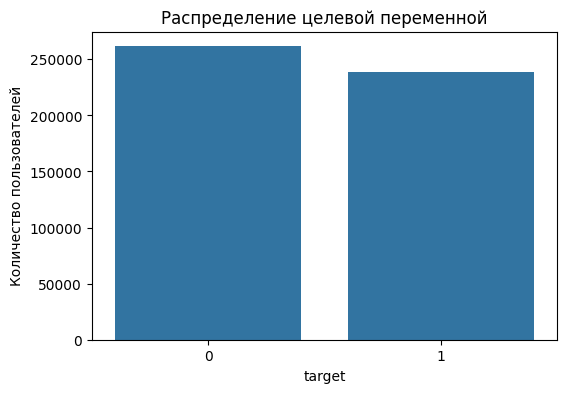

In [56]:
plt.figure(figsize=(6, 4))
sns.countplot(data=train_labels, x="target")
plt.title("Распределение целевой переменной")
plt.xlabel("target")
plt.ylabel("Количество пользователей")
plt.show()


Опять же целевая переменная достаточно сбалансирована

#### Количество событий на пользователя

In [57]:
events_per_user = train_full.groupby("user_id").size()
events_per_user.sample(5)

user_id
460af139369bc14095ba900dd627c1cd    1
2f3da3f35499c9756bbb270792d08735    1
384ea59848d6c70e71cd230eec127c26    1
77d7178bde5badda8e102e24193c5930    1
836919e33de2126a14d09c56467c1096    1
dtype: int64

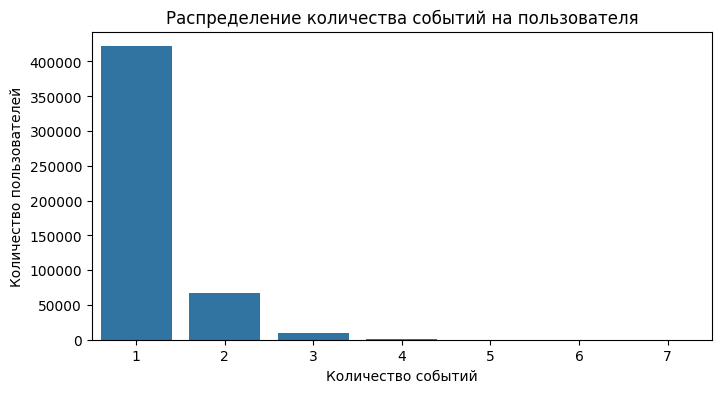

In [58]:
events_count_distribution = events_per_user.value_counts().sort_index().reset_index()
events_count_distribution.columns = ["events_count", "users_count"]

plt.figure(figsize=(8, 4))
sns.barplot(data=events_count_distribution, x="events_count", y="users_count")
plt.title("Распределение количества событий на пользователя")
plt.xlabel("Количество событий")
plt.ylabel("Количество пользователей")
plt.show()


In [59]:
events_count_distribution

,events_count,users_count
0,1,421582
1,2,66748
2,3,10111
3,4,1387
4,5,157
5,6,13
6,7,2


Большинство пользователей имеют только одно рекламное событие

#### Временные признаки

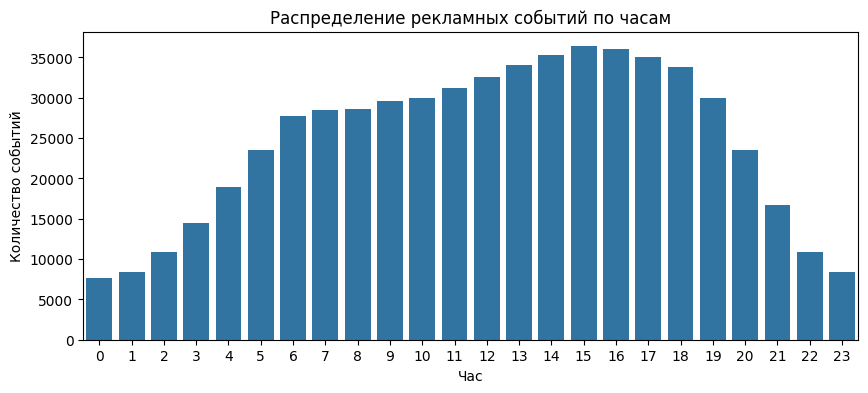

In [60]:
plt.figure(figsize=(10, 4))
sns.countplot(data=train_full, x="request_hour")
plt.title("Распределение рекламных событий по часам")
plt.xlabel("Час")
plt.ylabel("Количество событий")
plt.show()

Распределение рекламных событий по часам неравномерно. Наименьшая активность наблюдается ночью, а максимальная во второй половине дня. В целом временные признаки могут быть полезны для модели. При этом `request_ts` может являться серверным timestamp, поэтому интерпретировать часы как локальное время пользователя нужно осторожно.

#### Географические признаки

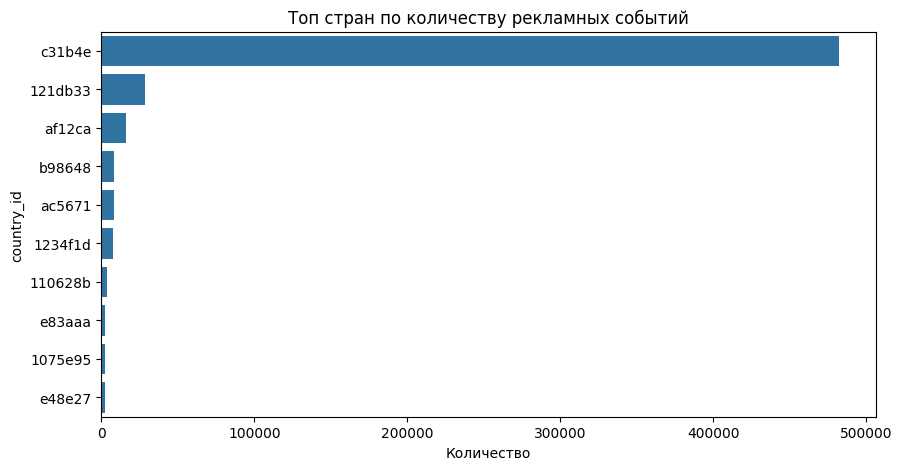

,country_id,count
0,c31b4e,482325
1,121db33,28679
2,af12ca,16412
3,b98648,8249
4,ac5671,8179
5,1234f1d,7719
6,110628b,3519
7,e83aaa,2529
8,1075e95,2525
9,e48e27,2454


In [61]:
country_counts = plot_top_categories(
    train_full,
    column="country_id",
    title="Топ стран по количеству рекламных событий",
    top_n=10,
)

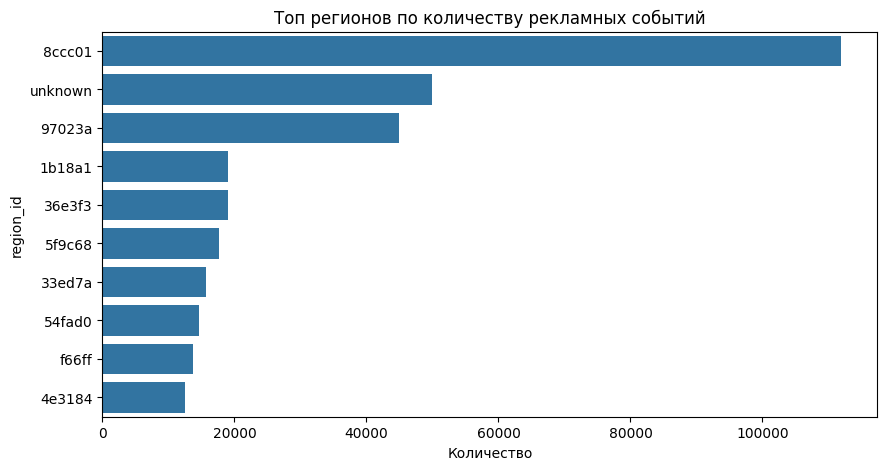

,region_id,count
0,8ccc01,111826
1,unknown,49903
2,97023a,44903
3,1b18a1,19085
4,36e3f3,19078
5,5f9c68,17687
6,33ed7a,15724
7,54fad0,14685
8,f66ff,13670
9,4e3184,12487


In [62]:
region_counts = plot_top_categories(
    train_full,
    column="region_id",
    title="Топ регионов по количеству рекламных событий",
    top_n=10,
)

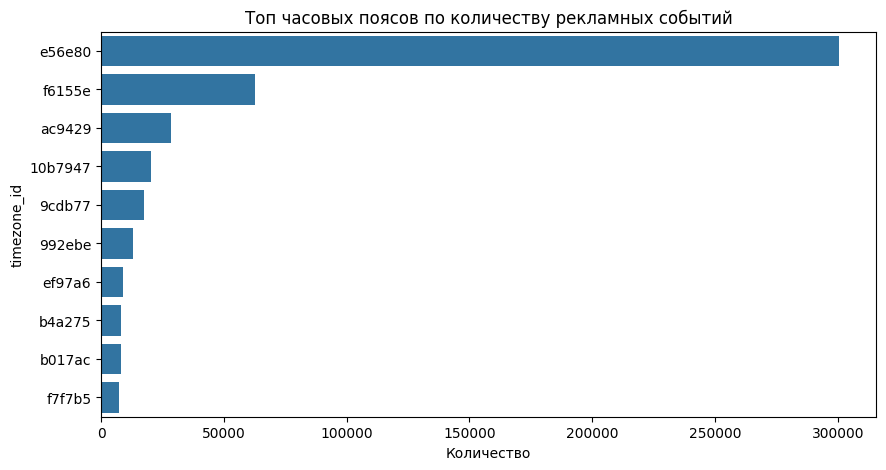

,timezone_id,count
0,e56e80,300546
1,f6155e,62736
2,ac9429,28679
3,10b7947,20255
4,9cdb77,17687
5,992ebe,13049
6,ef97a6,8826
7,b4a275,8246
8,b017ac,8179
9,f7f7b5,7512


In [63]:
timezone_counts = plot_top_categories(
    train_full,
    column="timezone_id",
    title="Топ часовых поясов по количеству рекламных событий",
    top_n=10,
)

большая часть событий относится к ограниченному числу стран, регионов и часовых поясов. Значение `unknown` в `region_id` встречается часто, поэтому его стоит сохранить как отдельную категорию

#### Referer

In [64]:
print(f"Уникальных referer: {train_full['referer'].nunique()}")
print(f"Уникальных доменов: {train_full['referer_domain'].nunique()}")
print(f"Уникальных path: {train_full['referer_path'].nunique()}")

Уникальных referer: 135012
Уникальных доменов: 4998
Уникальных path: 129332


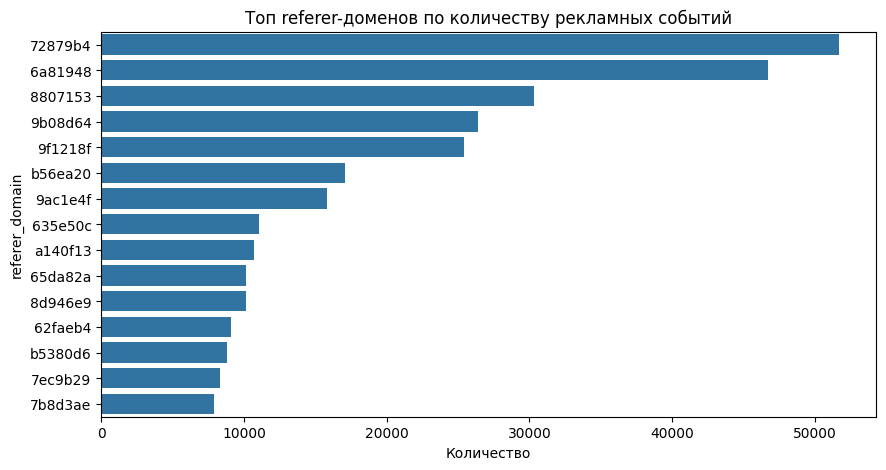

,referer_domain,count
0,72879b4,51716
1,6a81948,46724
2,8807153,30325
3,9b08d64,26365
4,9f1218f,25443
5,b56ea20,17098
6,9ac1e4f,15832
7,635e50c,11059
8,a140f13,10665
9,65da82a,10133


In [65]:
domain_counts = plot_top_categories(
    train_full,
    column="referer_domain",
    title="Топ referer-доменов по количеству рекламных событий",
    top_n=15,
)

Полный `referer` имеет очень высокую кардинальность, поэтому использовать его напрямую как категориальный признак может быть неэффективно. Более устойчивыми признаками в целом могут быть домен, путь и агрегаты по referer на уровне пользователя

#### User-agent

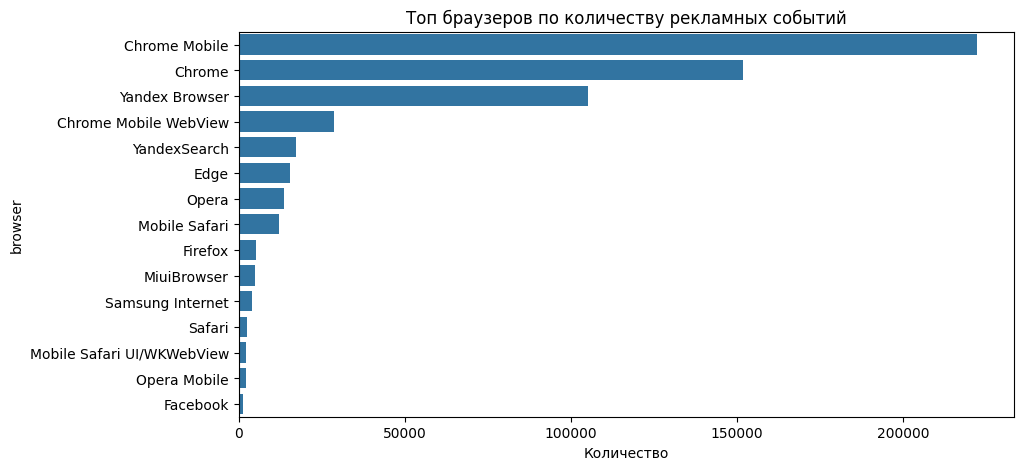

,browser,count
0,Chrome Mobile,222133
1,Chrome,151795
2,Yandex Browser,105252
3,Chrome Mobile WebView,28680
4,YandexSearch,17277
5,Edge,15393
6,Opera,13517
7,Mobile Safari,12243
8,Firefox,5351
9,MiuiBrowser,4897


In [66]:
browser_counts = plot_top_categories(
    train_full,
    column="browser",
    title="Топ браузеров по количеству рекламных событий",
    top_n=15,
)

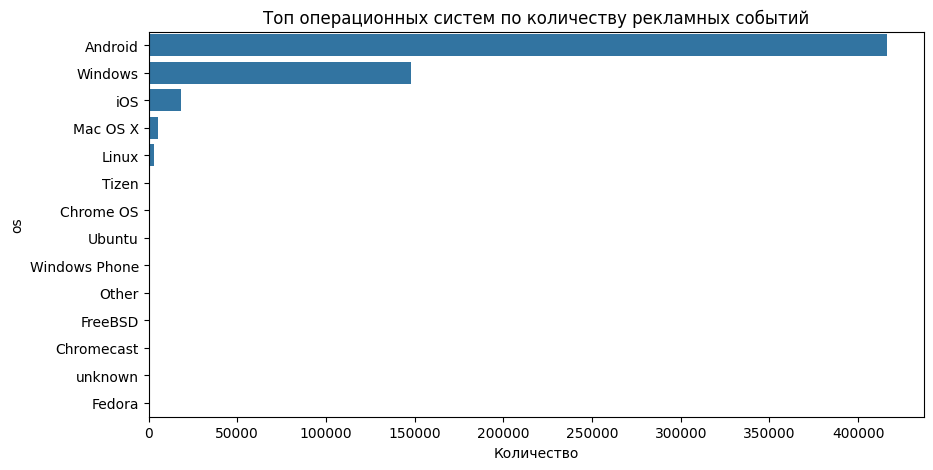

,os,count
0,Android,416023
1,Windows,148090
2,iOS,18428
3,Mac OS X,5455
4,Linux,2980
5,Tizen,609
6,Chrome OS,114
7,Ubuntu,103
8,Windows Phone,12
9,Other,9


In [67]:
os_counts = plot_top_categories(
    train_full,
    column="os",
    title="Топ операционных систем по количеству рекламных событий",
    top_n=15,
)

В данных доминируют мобильные браузеры и Android

### Multivariate analysis

Здесь анализируем связи между признаками и целевой переменной

Вспомогательная функция для графиков

Для категориальных признаков построим графики распределения `target` внутри наиболее частых категорий. Редкие категории отфильтруем по минимальному количеству пользователей, чтобы не делать выводы по слишком малым группам

In [68]:
def plot_target_shares_by_category(data, category_col, min_count=500, top_n=15):
    category_counts = data[category_col].value_counts()
    top_categories = category_counts[category_counts >= min_count].head(top_n).index
    plot_data = data[data[category_col].isin(top_categories)]
    target_shares = pd.crosstab(
        plot_data[category_col], plot_data["target"], normalize="index"
    )
    target_shares["users_count"] = plot_data[category_col].value_counts()
    target_shares = target_shares.sort_values("users_count", ascending=False)
    target_shares[[0, 1]].plot(kind="barh", stacked=True, figsize=(10, 5))
    plt.title(f"Распределение target по {category_col}")
    plt.xlabel("Доля пользователей")
    plt.ylabel(category_col)
    plt.xlim(0, 1)
    plt.legend(title="target")
    plt.show()

    display(target_shares)

    return target_shares

#### Количество событий и target

In [69]:
events_target = (
    train_full.groupby(["user_id", "target"]).size().reset_index(name="events_count")
)

events_target.groupby("target")["events_count"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,261520.0000,1.1798,0.4542,1.0000,1.0000,1.0000,1.0000,6.0000
1,238480.0000,1.1880,0.4658,1.0000,1.0000,1.0000,1.0000,7.0000


Количество рекламных событий на пользователя почти не отличается между классами `target`. У большинства пользователей есть только одно событие, поэтому сам по себе признак количества событий вероятно не будет сильным разделяющим признаком

#### Время запроса и target

In [70]:
hour_target_shares = pd.crosstab(eda_user["request_hour"], eda_user["target"], normalize="index")
hour_target_shares

target,0,1
request_hour,,
0,0.4570,0.5430
1,0.4699,0.5301
2,0.4971,0.5029
3,0.4959,0.5041
4,0.5088,0.4912
5,0.5121,0.4879
6,0.5351,0.4649
7,0.5341,0.4659
8,0.5339,0.4661


In [71]:
hour_target_shares["users_count"] = eda_user["request_hour"].value_counts()
hour_target_shares = hour_target_shares.sort_index()

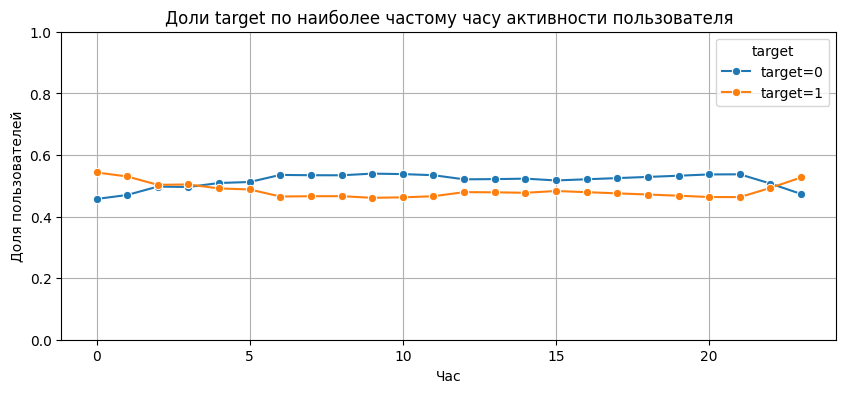

In [72]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=hour_target_shares, x=hour_target_shares.index, y=0, marker="o", label="target=0")
sns.lineplot(data=hour_target_shares, x=hour_target_shares.index, y=1, marker="o", label="target=1")

plt.title("Доли target по наиболее частому часу активности пользователя")
plt.xlabel("Час")
plt.ylabel("Доля пользователей")
plt.ylim(0, 1)
plt.grid(True)
plt.legend(title="target")
plt.show()

Доли классов `target=0` и `target=1` меняются по часам активности пользователя, однако различия не являются резкими. Временной признак может быть полезен как дополнительный, но вряд ли будет ключевым для модели

#### География и target

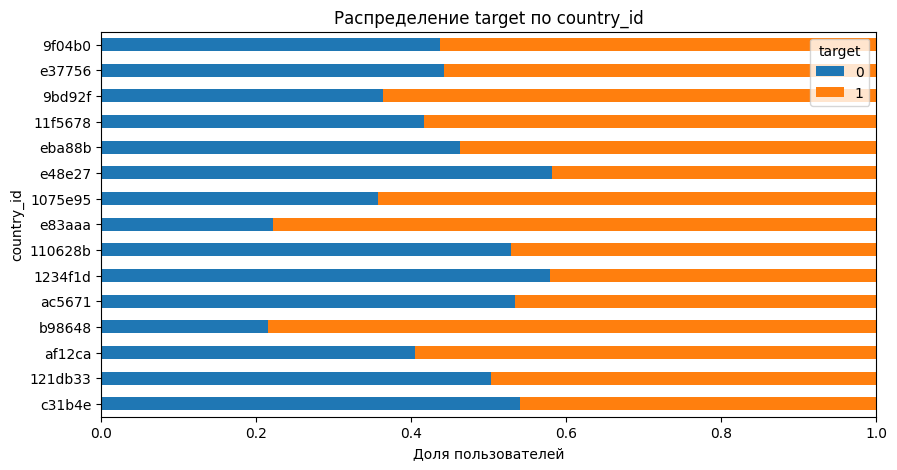

target,0,1,users_count
country_id,,,
c31b4e,0.5400,0.4600,405882
121db33,0.5030,0.4970,24811
af12ca,0.4042,0.5958,14091
b98648,0.2152,0.7848,7283
ac5671,0.5342,0.4658,6877
1234f1d,0.5791,0.4209,6520
110628b,0.5290,0.4710,3004
e83aaa,0.2219,0.7781,2199
1075e95,0.3568,0.6432,2192


In [73]:
country_target_stats = plot_target_shares_by_category(eda_user, category_col="country_id",min_count=500, top_n=15)

По странам различия самые заметные. Например, в самой массовой стране c31b4e доля классов близка к общей структуре: target=0 - 54%, target=1 - 46%. Но в некоторых достаточно крупных странах распределение сильно смещено

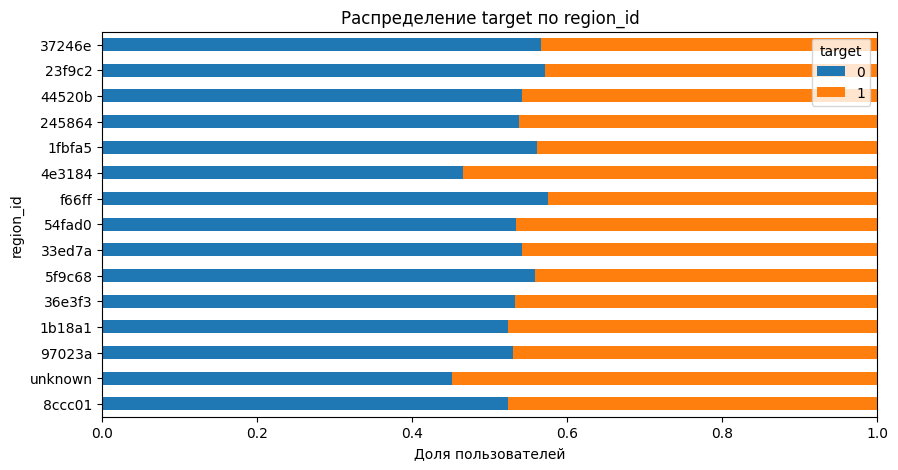

target,0,1,users_count
region_id,,,
8ccc01,0.5235,0.4765,93835
unknown,0.4506,0.5494,42888
97023a,0.5303,0.4697,37677
1b18a1,0.5240,0.4760,16100
36e3f3,0.5321,0.4679,16084
5f9c68,0.5578,0.4422,15031
33ed7a,0.5412,0.4588,13336
54fad0,0.5339,0.4661,12408
f66ff,0.5745,0.4255,11564


In [74]:
region_target_stats = plot_target_shares_by_category(eda_user, category_col="region_id", min_count=500, top_n=15)

По регионам различия более умеренные. Категория unknown заметная по размеру - 42888 пользователей, и у нее доля target=1 выше, чем у многих известных регионов. Скорее всего отсутствие региона действительно можно оставить отдельной категорией

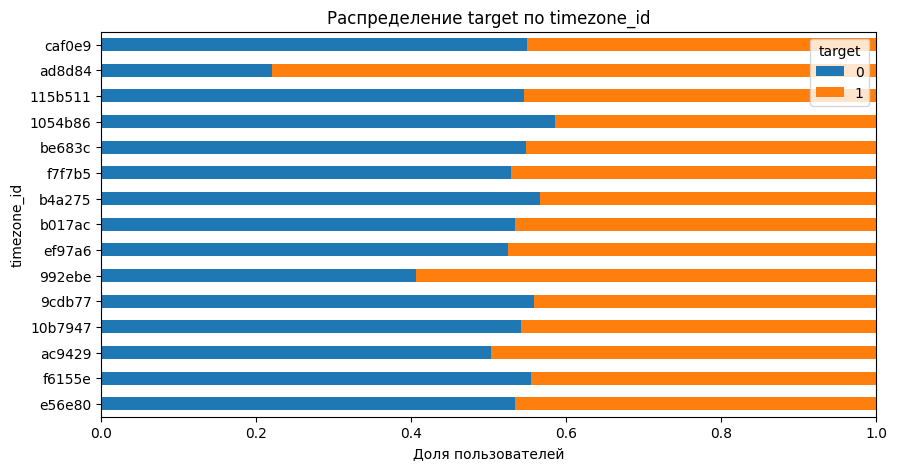

target,0,1,users_count
timezone_id,,,
e56e80,0.5336,0.4664,252687
f6155e,0.5540,0.4460,52839
ac9429,0.5030,0.4970,24811
10b7947,0.5418,0.4582,17120
9cdb77,0.5578,0.4422,15031
992ebe,0.4064,0.5936,11203
ef97a6,0.5244,0.4756,7485
b017ac,0.5342,0.4658,6877
b4a275,0.5664,0.4336,6833


In [75]:
timezone_target_stats = plot_target_shares_by_category(eda_user, category_col="timezone_id", min_count=500, top_n=15)

По часовым поясам тоже есть сигнал. Большинство крупных timezone_id близки к общему распределению, но есть заметные исключения

#### Browser / OS и target

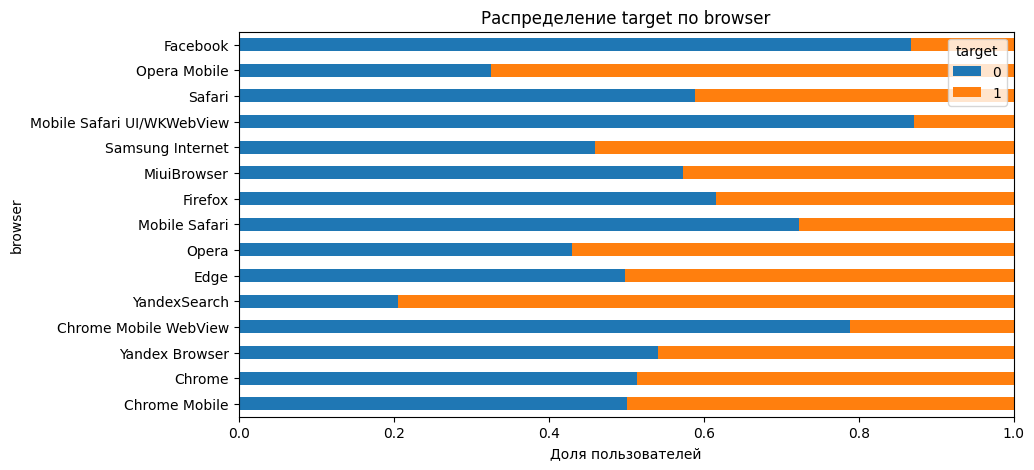

target,0,1,users_count
browser,,,
Chrome Mobile,0.5007,0.4993,192198
Chrome,0.5146,0.4854,125076
Yandex Browser,0.5405,0.4595,86902
Chrome Mobile WebView,0.7893,0.2107,24720
YandexSearch,0.2054,0.7946,15050
Edge,0.4990,0.5010,12555
Opera,0.4307,0.5693,10995
Mobile Safari,0.7228,0.2772,10540
Firefox,0.6154,0.3846,4376


In [76]:
browser_target_stats = plot_target_shares_by_category(eda_user, category_col="browser", min_count=500, top_n=15)

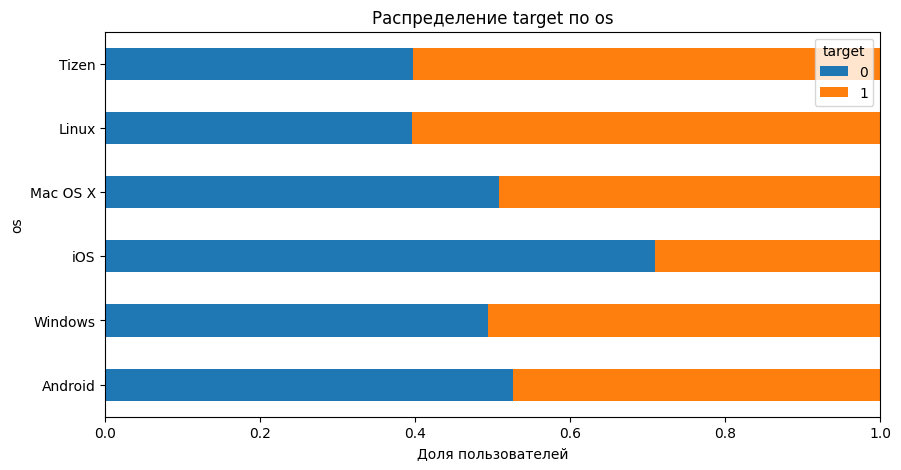

target,0,1,users_count
os,,,
Android,0.5257,0.4743,355454
Windows,0.4941,0.5059,120746
iOS,0.7098,0.2902,16016
Mac OS X,0.5075,0.4925,4550
Linux,0.3954,0.6046,2514
Tizen,0.3969,0.6031,514


In [77]:
os_target_stats = plot_target_shares_by_category(eda_user, category_col="os", min_count=500, top_n=15)

Браузер и операционная система показывают различия в распределении `target`. Поэтому признаки из `user_agent` стоит использовать при построении модели

#### Referer domain, url-векторы и target

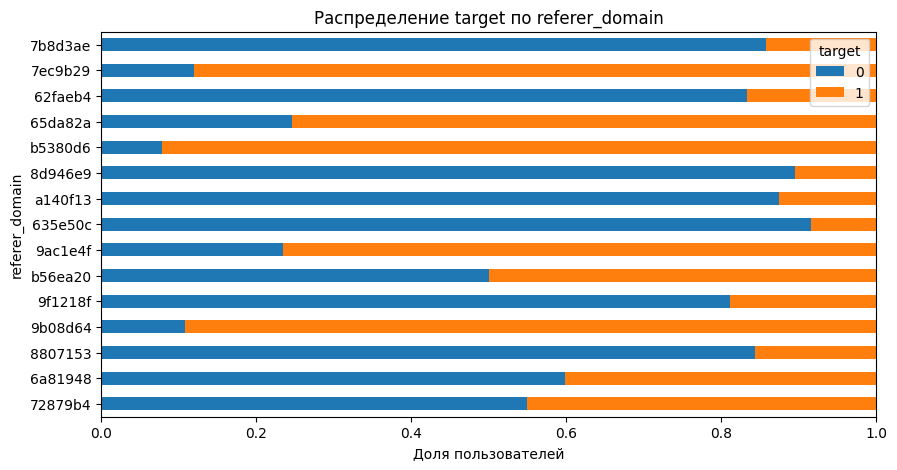

target,0,1,users_count
referer_domain,,,
72879b4,0.5492,0.4508,41312
6a81948,0.5980,0.4020,39684
8807153,0.8436,0.1564,24809
9b08d64,0.1079,0.8921,22547
9f1218f,0.8112,0.1888,21545
b56ea20,0.5009,0.4991,13813
9ac1e4f,0.2347,0.7653,12537
635e50c,0.9157,0.0843,10181
a140f13,0.8738,0.1262,9067


In [78]:
domain_target_stats = plot_target_shares_by_category(eda_user, category_col="referer_domain", min_count=500, top_n=15)

По `referer_domain` наблюдаются наиболее выраженные различия в распределении целевой переменной. Некоторые домены имеют сильное смещение в сторону `target=1`, например `9b08d64`, `b5380d6`, `7ec9b29`, тогда как другие домены. заметно смещены в сторону `target=0`, например `635e50c`, `8d946e9`, `a140f13`, `8807153`

Так как эти категории представлены большим количеством пользователей, различия нельзя объяснить только случайным шумом. Это говорит о том, что информация о домене, на котором был зафиксирован рекламный запрос, может быть одним из наиболее полезных источников признаков для модели

In [79]:
component_target_mean = train_full.groupby("target")[component_cols].mean().T
component_target_mean["difference"] = component_target_mean[1] - component_target_mean[0]
component_target_mean.sort_values("difference", ascending=False)

target,0,1,difference
component8,2105.7268,6101.0116,3995.2848
component1,5105.4362,8956.1191,3850.6830
component5,6573.1076,7818.4415,1245.3339
component6,2910.4889,3922.1699,1011.6810
component0,10562.2511,11283.3110,721.0599
component4,8608.6928,9115.3484,506.6556
component9,6035.1738,6109.9840,74.8102
component7,4997.8514,4089.0668,-908.7846
component2,6771.5798,4910.6683,-1860.9115
component3,4601.9045,1816.6608,-2785.2437


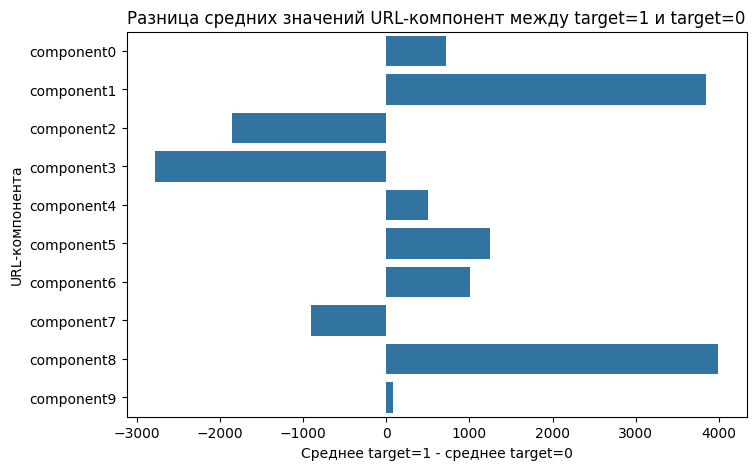

target,0,1,difference
component0,10562.2511,11283.3110,721.0599
component1,5105.4362,8956.1191,3850.6830
component2,6771.5798,4910.6683,-1860.9115
component3,4601.9045,1816.6608,-2785.2437
component4,8608.6928,9115.3484,506.6556
component5,6573.1076,7818.4415,1245.3339
component6,2910.4889,3922.1699,1011.6810
component7,4997.8514,4089.0668,-908.7846
component8,2105.7268,6101.0116,3995.2848
component9,6035.1738,6109.9840,74.8102


In [80]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=component_target_mean.reset_index(),
    x="difference",
    y="index",
)
plt.title("Разница средних значений URL-компонент между target=1 и target=0")
plt.xlabel("Среднее target=1 - среднее target=0")
plt.ylabel("URL-компонента")
plt.show()

component_target_mean

Средние значения некоторых URL-компонент заметно различаются между классами. Так как компоненты не имеют прямой бизнес-интерпретации, их нельзя содержательно объяснять, но они могут быть полезными числовыми признаками для модели

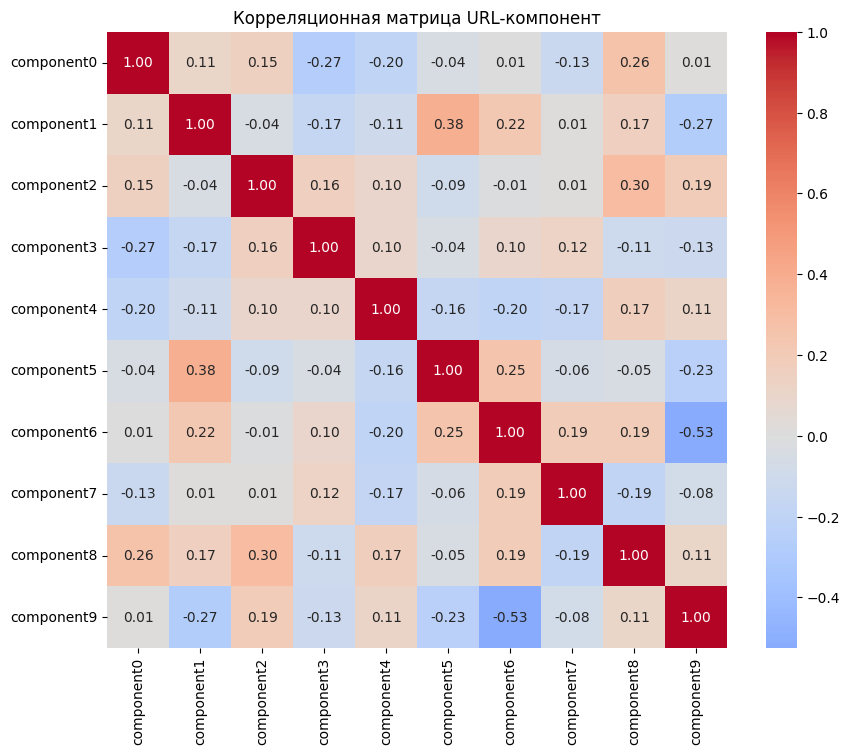

In [81]:
plt.figure(figsize=(10, 8))
sns.heatmap(train_full[component_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляционная матрица URL-компонент")
plt.show()

Корреляционная матрица URL-компонент показывает, что большинство компонент имеют слабую или умеренную связь между собой. Наиболее заметная отрицательная корреляция наблюдается между `component6` и `component9`, около -0.53. Это говорит о том, что часть URL-компонент может содержать пересекающуюся информацию, но критичной мультиколлинеарности не наблюдается

In [82]:
train_full[component_cols + ["target"]].corr()["target"].drop("target").sort_values(ascending=False)

component1    0.2580
component8    0.2071
component5    0.1059
component6    0.0655
component0    0.0543
component4    0.0344
component9    0.0032
component7   -0.0615
component2   -0.1201
component3   -0.1955
Name: target, dtype: float64

Корреляция URL-компонент с целевой переменной показывает, что отдельные компоненты имеют заметную линейную связь с `target`. Наибольшая положительная корреляция наблюдается у `component1` и `component8`, а наиболее выраженная отрицательная  у `component3` и `component2`. При этом корреляция отражает только линейную зависимость. Даже компоненты со слабой корреляцией могут быть полезны для нелинейных моделей, поэтому на этапе моделирования URL-компоненты будут сохранены как признаки

#### Выводы по EDA

В ходе разведочного анализа было подтверждено, что данные имеют событийную структуру: одна строка соответствует рекламному событию, а предсказание требуется делать на уровне пользователя. Поэтому на следующем этапе данные необходимо агрегировать до уровня `user_id`.

- Целевая переменная достаточно сбалансирована, поэтому специальная балансировка классов на первом этапе не требуется.
- Большинство пользователей имеют только одно рекламное событие, поэтому количество событий само по себе не является сильным разделяющим признаком. Более важными могут быть признаки самого события: география, время, user-agent, referer и URL-векторы.
- Географические признаки показывают связь с целевой переменной, особенно на уровне `country_id` и отдельных `timezone_id`. Категорию `unknown` в `region_id` стоит сохранить как отдельное значение.
- Признаки из `user_agent`, такие как браузер и операционная система, также различаются по распределению целевой переменной и могут быть полезны для модели.
- Наиболее выраженный сигнал наблюдается у `referer_domain`. некоторые домены сильно смещены в сторону `target=0`, другие в сторону `target=1`. Поэтому признаки, связанные с доменами и URL-векторами вероятно будут одними из наиболее полезных. URL-векторы также показывают различия между классами по средним значениям отдельных компонент. Несмотря на отсутствие прямой интерпретации, их стоит использовать как числовые признаки.

## Feature engineering

Исходные таблицы `train_full` и `test_full` находятся на уровне рекламных событий.  
Так как предсказание нужно делать для каждого `user_id`, агрегируем данные до уровня пользователя.

In [83]:
train_fe = train_full.copy()
test_fe = test_full.copy()

In [84]:
train_fe.shape, test_fe.shape

((591836, 30), (102667, 29))

In [85]:
train_fe.columns

Index(['request_ts', 'user_id', 'referer', 'geo_id', 'user_agent',
       'request_datetime', 'component0', 'component1', 'component2',
       'component3', 'component4', 'component5', 'component6', 'component7',
       'component8', 'component9', 'country_id', 'region_id', 'timezone_id',
       'target', 'request_hour', 'request_date', 'referer_domain',
       'referer_path', 'browser', 'browser_version', 'os', 'os_version',
       'browser_version_major', 'os_version_major'],
      dtype='str')

Часть признаков уже была создана на этапе EDA и находится в `train_full` и `test_full`:

- `request_hour`
- `referer_domain`
- `browser`
- `os`

Поэтому на этапе feature engineering не будем создавать их повторно.

Создадим функцию для агрегации до user_id

Для каждого пользователя посчитаем:

- количество событий
- количество уникальных URL, доменов и географических значений
- первый и последний час активности
- первые значения категориальных признаков
- агрегаты по URL-компонентам

Отдельно сохраним список URL-компонент и категориальных признаков

In [86]:
component_cols = [f"component{i}" for i in range(10)]
cat_cols = ["country_id", "region_id", "timezone_id", "referer_domain", "browser", "os"]

Отсортируем события по пользователю и времени, чтобы корректно взять первое значение признака у пользователя

In [87]:
train_fe_sorted = train_fe.sort_values(["user_id", "request_datetime"])
test_fe_sorted = test_fe.sort_values(["user_id", "request_datetime"])

Посчитаем количество событий пользователя и количество уникальных значений по URL и географии

In [88]:
train_base_features = train_fe.groupby("user_id", as_index=False).agg(
    events_count=("user_id", "size"),
    unique_referer_count=("referer", "nunique"),
    unique_referer_domain_count=("referer_domain", "nunique"),
    unique_geo_id_count=("geo_id", "nunique"),
    unique_country_count=("country_id", "nunique"),
    unique_region_count=("region_id", "nunique"),
    unique_timezone_count=("timezone_id", "nunique"),
)

In [89]:
train_base_features.head()

,user_id,events_count,unique_referer_count,unique_referer_domain_count,unique_geo_id_count,unique_country_count,unique_region_count,unique_timezone_count
0,00006a10d9ff5f9d312029ac4d296430,1,1,1,1,1,1,1
1,00008d5fd6bff19884138510b077a22b,1,1,1,1,1,1,1
2,000098f8aa8b68a125148caff0a02827,1,1,1,1,1,1,1
3,0000b0ec7cb23e402cc5bb0487deef4c,2,2,2,1,1,1,1
4,0000be6a07f2fcfd68b8486d309e3a22,1,1,1,1,1,1,1


In [90]:
test_base_features = test_fe.groupby("user_id", as_index=False).agg(
    events_count=("user_id", "size"),
    unique_referer_count=("referer", "nunique"),
    unique_referer_domain_count=("referer_domain", "nunique"),
    unique_geo_id_count=("geo_id", "nunique"),
    unique_country_count=("country_id", "nunique"),
    unique_region_count=("region_id", "nunique"),
    unique_timezone_count=("timezone_id", "nunique"),
)

Возьмем первый и последний час рекламного события пользователя

In [91]:
train_time_features = train_fe_sorted.groupby("user_id", as_index=False).agg(
    first_request_hour=("request_hour", "first"),
    last_request_hour=("request_hour", "last"),
)

In [92]:
train_time_features.head()

,user_id,first_request_hour,last_request_hour
0,00006a10d9ff5f9d312029ac4d296430,7,7
1,00008d5fd6bff19884138510b077a22b,3,3
2,000098f8aa8b68a125148caff0a02827,13,13
3,0000b0ec7cb23e402cc5bb0487deef4c,4,20
4,0000be6a07f2fcfd68b8486d309e3a22,21,21


In [93]:
test_time_features = test_fe_sorted.groupby("user_id", as_index=False).agg(
    first_request_hour=("request_hour", "first"),
    last_request_hour=("request_hour", "last"),
)

Для категориальных признаков возьмем первое значение пользователя по времени. Это простой подход, который хорошо подходит для текущих данных, потому что у большинства пользователей только одно событие

In [94]:
train_cat_features = train_fe_sorted.groupby("user_id", as_index=False).agg(
    country_id=("country_id", "first"),
    region_id=("region_id", "first"),
    timezone_id=("timezone_id", "first"),
    referer_domain=("referer_domain", "first"),
    browser=("browser", "first"),
    os=("os", "first"),
)

In [95]:
train_cat_features.head()

,user_id,country_id,region_id,timezone_id,referer_domain,browser,os
0,00006a10d9ff5f9d312029ac4d296430,c31b4e,470e75,f6155e,6a81948,YandexSearch,Android
1,00008d5fd6bff19884138510b077a22b,c31b4e,1fbfa5,e56e80,6a81948,Yandex Browser,iOS
2,000098f8aa8b68a125148caff0a02827,e48e27,unknown,f0c3df,b53adc6,Chrome,Windows
3,0000b0ec7cb23e402cc5bb0487deef4c,c31b4e,97023a,e56e80,b6630fd,Chrome Mobile,Android
4,0000be6a07f2fcfd68b8486d309e3a22,c31b4e,380ef0,e56e80,9f1218f,Chrome Mobile WebView,Android


In [96]:
test_cat_features = test_fe_sorted.groupby("user_id", as_index=False).agg(
    country_id=("country_id", "first"),
    region_id=("region_id", "first"),
    timezone_id=("timezone_id", "first"),
    referer_domain=("referer_domain", "first"),
    browser=("browser", "first"),
    os=("os", "first"),
)

Посчитаем агрегаты по URL-компонентам

- среднее
- стандартное отклонение
- минимум
- максимум

In [97]:
train_component_features = train_fe.groupby("user_id")[component_cols].agg(
    ["mean", "std", "min", "max"]
)

In [98]:
test_component_features = test_fe.groupby("user_id")[component_cols].agg(
    ["mean", "std", "min", "max"]
)

In [99]:
train_component_features.head()

component0                           \
                                       mean        std    min    max   
user_id                                                                
00006a10d9ff5f9d312029ac4d296430 10214.0000        NaN  10214  10214   
00008d5fd6bff19884138510b077a22b 10214.0000        NaN  10214  10214   
000098f8aa8b68a125148caff0a02827 15633.0000        NaN  15633  15633   
0000b0ec7cb23e402cc5bb0487deef4c 12055.5000 10532.3555   4608  19503   
0000be6a07f2fcfd68b8486d309e3a22 -3578.0000        NaN  -3578  -3578   

                                 component1                          \
                                       mean       std    min    max   
user_id                                                               
00006a10d9ff5f9d312029ac4d296430 -1254.0000       NaN  -1254  -1254   
00008d5fd6bff19884138510b077a22b -1254.0000       NaN  -1254  -1254   
000098f8aa8b68a125148caff0a02827 22503.0000       NaN  22503  22503   
0000b0ec7cb23e402cc5bb0487deef4c 10011.5000 5087.6333   6414  13609   
0000be6a07f2fcfd68b8486d309e3a22  2164.0000       NaN   2164   2164   

                                  component2                          \
                                        mean       std    min    max   
user_id                                                                
00006a10d9ff5f9d312029ac4d296430  10495.0000       NaN  10495  10495   
00008d5fd6bff19884138510b077a22b  10495.0000       NaN  10495  10495   
000098f8aa8b68a125148caff0a02827  -2155.0000       NaN  -2155  -2155   
0000b0ec7cb23e402cc5bb0487deef4c  10496.0000 2173.6462   8959  12033   
0000be6a07f2fcfd68b8486d309e3a22 -12993.0000       NaN -12993 -12993   

                                 component3                       component4  \
                                       mean       std   min   max       mean   
user_id                                                                        
00006a10d9ff5f9d312029ac4d296430  7705.0000       NaN  7705  7705  9547.0000   
00008d5fd6bff19884138510b077a22b  7705.0000       NaN  7705  7705  9547.0000   
000098f8aa8b68a125148caff0a02827  -557.0000       NaN  -557  -557  2232.0000   
0000b0ec7cb23e402cc5bb0487deef4c -1075.0000 1105.9150 -1857  -293  9866.5000   
0000be6a07f2fcfd68b8486d309e3a22  5330.0000       NaN  5330  5330  5018.0000   

                                                         component5            \
                                        std   min    max       mean       std   
user_id                                                                         
00006a10d9ff5f9d312029ac4d296430        NaN  9547   9547  5801.0000       NaN   
00008d5fd6bff19884138510b077a22b        NaN  9547   9547  5801.0000       NaN   
000098f8aa8b68a125148caff0a02827        NaN  2232   2232 16084.0000       NaN   
0000b0ec7cb23e402cc5bb0487deef4c 15084.7090  -800  20533  8561.5000 3199.6582   
0000be6a07f2fcfd68b8486d309e3a22        NaN  5018   5018  8603.0000       NaN   

                                               component6                  \
                                    min    max       mean       std   min   
user_id                                                                     
00006a10d9ff5f9d312029ac4d296430   5801   5801   864.0000       NaN   864   
00008d5fd6bff19884138510b077a22b   5801   5801   864.0000       NaN   864   
000098f8aa8b68a125148caff0a02827  16084  16084   -87.0000       NaN   -87   
0000b0ec7cb23e402cc5bb0487deef4c   6299  10824  -249.0000 6549.2230 -4880   
0000be6a07f2fcfd68b8486d309e3a22   8603   8603 -2646.0000       NaN -2646   

                                       component7                         \
                                   max       mean       std    min   max   
user_id                                                                    
00006a10d9ff5f9d312029ac4d296430   864  8837.0000       NaN   8837  8837   
00008d5fd6bff19884138510b077a22b   864  8837.0000       NaN   8837  8837   
000098f8aa8b68a125148ca

In [100]:
train_component_features.columns = [f"{col}_{stat}" for col, stat in train_component_features.columns]
test_component_features.columns = [f"{col}_{stat}" for col, stat in test_component_features.columns]

In [101]:
train_component_features = train_component_features.reset_index()
test_component_features = test_component_features.reset_index()

In [102]:
train_component_features.head()

,user_id,component0_mean,component0_std,component0_min,component0_max,component1_mean,component1_std,component1_min,component1_max,component2_mean,component2_std,component2_min,component2_max,component3_mean,component3_std,component3_min,component3_max,component4_mean,component4_std,component4_min,component4_max,component5_mean,component5_std,component5_min,component5_max,component6_mean,component6_std,component6_min,component6_max,component7_mean,component7_std,component7_min,component7_max,component8_mean,component8_std,component8_min,component8_max,component9_mean,component9_std,component9_min,component9_max
0,00006a10d9ff5f9d312029ac4d296430,10214.0000,NaN,10214,10214,-1254.0000,NaN,-1254,-1254,10495.0000,NaN,10495,10495,7705.0000,NaN,7705,7705,9547.0000,NaN,9547,9547,5801.0000,NaN,5801,5801,864.0000,NaN,864,864,8837.0000,NaN,8837,8837,5312.0000,NaN,5312,5312,22635.0000,NaN,22635,22635
1,00008d5fd6bff19884138510b077a22b,10214.0000,NaN,10214,10214,-1254.0000,NaN,-1254,-1254,10495.0000,NaN,10495,10495,7705.0000,NaN,7705,7705,9547.0000,NaN,9547,9547,5801.0000,NaN,5801,5801,864.0000,NaN,864,864,8837.0000,NaN,8837,8837,5312.0000,NaN,5312,5312,22635.0000,NaN,22635,22635
2,000098f8aa8b68a125148caff0a02827,15633.0000,NaN,15633,15633,22503.0000,NaN,22503,22503,-2155.0000,NaN,-2155,-2155,-557.0000,NaN,-557,-557,2232.0000,NaN,2232,2232,16084.0000,NaN,16084,16084,-87.0000,NaN,-87,-87,-2820.0000,NaN,-2820,-2820,6578.0000,NaN,6578,6578,3085.0000,NaN,3085,3085
3,0000b0ec7cb23e402cc5bb0487deef4c,12055.5000,10532.3555,4608,19503,10011.5000,5087.6333,6414,13609,10496.0000,2173.6462,8959,12033,-1075.0000,1105.9150,-1857,-293,9866.5000,15084.7090,-800,20533,8561.5000,3199.6582,6299,10824,-249.0000,6549.2230,-4880,4382,-7344.5000,3847.3680,-10065,-4624,12256.5000,1050.0536,11514,12999,10378.5000,3810.5984,7684,13073
4,0000be6a07f2fcfd68b8486d309e3a22,-3578.0000,NaN,-3578,-3578,2164.0000,NaN,2164,2164,-12993.0000,NaN,-12993,-12993,5330.0000,NaN,5330,5330,5018.0000,NaN,5018,5018,8603.0000,NaN,8603,8603,-2646.0000,NaN,-2646,-2646,8588.0000,NaN,8588,8588,-30424.0000,NaN,-30424,-30424,-4684.0000,NaN,-4684,-4684


Если у пользователя только одно событие, стандартное отклонение не рассчитывается и получается пропуск.  
Заменим такие значения на 0

In [103]:
std_cols = [col for col in train_component_features.columns if col.endswith("_std")]

train_component_features[std_cols] = train_component_features[std_cols].fillna(0)
test_component_features[std_cols] = test_component_features[std_cols].fillna(0)

In [104]:
print("Пропуски в std train:", train_component_features[std_cols].isna().sum().sum())
print("Пропуски в std test:", test_component_features[std_cols].isna().sum().sum())

Пропуски в std train: 0
Пропуски в std test: 0


Объединим все признаки в одну таблицу

In [105]:
train_user_features = (
    train_base_features.merge(train_time_features, on="user_id", how="left")
    .merge(train_cat_features, on="user_id", how="left")
    .merge(train_component_features, on="user_id", how="left")
)

In [106]:
test_user_features = (
    test_base_features.merge(test_time_features, on="user_id", how="left")
    .merge(test_cat_features, on="user_id", how="left")
    .merge(test_component_features, on="user_id", how="left")
)

In [107]:
test_user_features = test_users.merge(test_user_features, on="user_id", how="left")

In [108]:
assert test_user_features["user_id"].equals(test_users["user_id"])

In [109]:
train_user_features = train_labels.merge(train_user_features, on="user_id", how="left")

In [110]:
train_user_features.shape, test_user_features.shape

((500000, 57), (85000, 56))

In [111]:
train_user_features.head()

,user_id,target,events_count,unique_referer_count,unique_referer_domain_count,unique_geo_id_count,unique_country_count,unique_region_count,unique_timezone_count,first_request_hour,last_request_hour,country_id,region_id,timezone_id,referer_domain,browser,os,component0_mean,component0_std,component0_min,component0_max,component1_mean,component1_std,component1_min,component1_max,component2_mean,component2_std,component2_min,component2_max,component3_mean,component3_std,component3_min,component3_max,component4_mean,component4_std,component4_min,component4_max,component5_mean,component5_std,component5_min,component5_max,component6_mean,component6_std,component6_min,component6_max,component7_mean,component7_std,component7_min,component7_max,component8_mean,component8_std,component8_min,component8_max,component9_mean,component9_std,component9_min,component9_max
0,fb858e8e0a2bec074450eaf94b627fd3,0,1,1,1,1,1,1,1,15,15,c31b4e,470e75,f6155e,9b48ee5,Chrome Mobile,Android,11731.0000,0.0000,11731,11731,4045.0000,0.0000,4045,4045,22213.0000,0.0000,22213,22213,-1184.0000,0.0000,-1184,-1184,-8992.0000,0.0000,-8992,-8992,9381.0000,0.0000,9381,9381,-3496.0000,0.0000,-3496,-3496,-3120.0000,0.0000,-3120,-3120,-899.0000,0.0000,-899,-899,16817.0000,0.0000,16817,16817
1,46a5f128fd569c764a92c2eaa788095e,0,1,1,1,1,1,1,1,8,8,c31b4e,44520b,e56e80,9b48ee5,Chrome Mobile,Android,11731.0000,0.0000,11731,11731,4045.0000,0.0000,4045,4045,22213.0000,0.0000,22213,22213,-1184.0000,0.0000,-1184,-1184,-8992.0000,0.0000,-8992,-8992,9381.0000,0.0000,9381,9381,-3496.0000,0.0000,-3496,-3496,-3120.0000,0.0000,-3120,-3120,-899.0000,0.0000,-899,-899,16817.0000,0.0000,16817,16817
2,5a74e9ac53ffb21a20cce117c0ad77ba,0,1,1,1,1,1,1,1,15,15,c31b4e,616bb9,af47f1,9634fd0,Yandex Browser,Android,12498.0000,0.0000,12498,12498,2451.0000,0.0000,2451,2451,10304.0000,0.0000,10304,10304,-6380.0000,0.0000,-6380,-6380,11608.0000,0.0000,11608,11608,3106.0000,0.0000,3106,3106,-2188.0000,0.0000,-2188,-2188,10573.0000,0.0000,10573,10573,3347.0000,0.0000,3347,3347,21870.0000,0.0000,21870,21870
3,af735816ca19115431ae3d89518c8c91,0,1,1,1,1,1,1,1,10,10,c31b4e,3c9dca,e56e80,9b48ee5,Chrome Mobile,Android,11731.0000,0.0000,11731,11731,4045.0000,0.0000,4045,4045,22213.0000,0.0000,22213,22213,-1184.0000,0.0000,-1184,-1184,-8992.0000,0.0000,-8992,-8992,9381.0000,0.0000,9381,9381,-3496.0000,0.0000,-3496,-3496,-3120.0000,0.0000,-3120,-3120,-899.0000,0.0000,-899,-899,16817.0000,0.0000,16817,16817
4,364f0ae0a3f29a685c4fb5bae6033b9a,0,2,1,1,1,1,1,1,18,18,c31b4e,776e76,10b7947,9b48ee5,Yandex Browser,Android,11731.0000,0.0000,11731,11731,4045.0000,0.0000,4045,4045,22213.0000,0.0000,22213,22213,-1184.0000,0.0000,-1184,-1184,-8992.0000,0.0000,-8992,-8992,9381.0000,0.0000,9381,9381,-3496.0000,0.0000,-3496,-3496,-3120.0000,0.0000,-3120,-3120,-899.0000,0.0000,-899,-899,16817.0000,0.0000,16817,16817


In [112]:
test_user_features.head()

,user_id,events_count,unique_referer_count,unique_referer_domain_count,unique_geo_id_count,unique_country_count,unique_region_count,unique_timezone_count,first_request_hour,last_request_hour,country_id,region_id,timezone_id,referer_domain,browser,os,component0_mean,component0_std,component0_min,component0_max,component1_mean,component1_std,component1_min,component1_max,component2_mean,component2_std,component2_min,component2_max,component3_mean,component3_std,component3_min,component3_max,component4_mean,component4_std,component4_min,component4_max,component5_mean,component5_std,component5_min,component5_max,component6_mean,component6_std,component6_min,component6_max,component7_mean,component7_std,component7_min,component7_max,component8_mean,component8_std,component8_min,component8_max,component9_mean,component9_std,component9_min,component9_max
0,c2802dadd33d8ae09bb366bdd41212ea,3,2,2,1,1,1,1,9,10,c31b4e,36e3f3,f6155e,8624dd2,Chrome Mobile,Android,5324.3333,11096.6722,-7489,11731,3815.3333,397.7943,3356,4045,18742.0000,6011.9484,11800,22213,-3918.3333,4736.0043,-9387,-1184,859.3333,17063.0099,-8992,20562,9817.0000,755.1742,9381,10689,2072.6667,9645.2136,-3496,13210,-2951.6667,291.5619,-3120,-2615,2651.6667,6149.9351,-899,9753,11578.6667,9073.0595,1102,16817
1,e5b1988db74527ec092f28b0bbfdaac9,1,1,1,1,1,1,1,13,13,c31b4e,8ccc01,e56e80,9b48ee5,Chrome,Android,11731.0000,0.0000,11731,11731,4045.0000,0.0000,4045,4045,22213.0000,0.0000,22213,22213,-1184.0000,0.0000,-1184,-1184,-8992.0000,0.0000,-8992,-8992,9381.0000,0.0000,9381,9381,-3496.0000,0.0000,-3496,-3496,-3120.0000,0.0000,-3120,-3120,-899.0000,0.0000,-899,-899,16817.0000,0.0000,16817,16817
2,6ef1eedbdb72554e53e69782066065c5,1,1,1,1,1,1,1,3,3,c31b4e,1fbfa5,e56e80,72879b4,Chrome,Android,-7307.0000,0.0000,-7307,-7307,11682.0000,0.0000,11682,11682,9741.0000,0.0000,9741,9741,13564.0000,0.0000,13564,13564,13577.0000,0.0000,13577,13577,1200.0000,0.0000,1200,1200,10169.0000,0.0000,10169,10169,16461.0000,0.0000,16461,16461,-3932.0000,0.0000,-3932,-3932,3340.0000,0.0000,3340,3340
3,7e057293ecae62985a327b7af51858ea,1,1,1,1,1,1,1,9,9,c31b4e,f66ff,f6155e,9b48ee5,Chrome Mobile,Android,11731.0000,0.0000,11731,11731,4045.0000,0.0000,4045,4045,22213.0000,0.0000,22213,22213,-1184.0000,0.0000,-1184,-1184,-8992.0000,0.0000,-8992,-8992,9381.0000,0.0000,9381,9381,-3496.0000,0.0000,-3496,-3496,-3120.0000,0.0000,-3120,-3120,-899.0000,0.0000,-899,-899,16817.0000,0.0000,16817,16817
4,a27bd7ce8828497823fa8d5d05e7bbf7,1,1,1,1,1,1,1,17,17,c31b4e,245864,e56e80,9b48ee5,Chrome Mobile,Android,11731.0000,0.0000,11731,11731,4045.0000,0.0000,4045,4045,22213.0000,0.0000,22213,22213,-1184.0000,0.0000,-1184,-1184,-8992.0000,0.0000,-8992,-8992,9381.0000,0.0000,9381,9381,-3496.0000,0.0000,-3496,-3496,-3120.0000,0.0000,-3120,-3120,-899.0000,0.0000,-899,-899,16817.0000,0.0000,16817,16817


Итоговые таблицы признаков собраны на уровне пользователя: одна строка соответствует одному `user_id`

In [113]:
print("Пропуски в train:", train_user_features.isna().sum().sum())
print("Пропуски в test:", test_user_features.isna().sum().sum())

Пропуски в train: 0
Пропуски в test: 0


Feature engineering завершен.

Сформированы две таблицы:
- `train_user_features` - обучающая таблица на уровне пользователя;
- `test_user_features` - тестовая таблица на уровне пользователя.


## Подготовка обучающей и валидационной выборок

Теперь подготовим данные для обучения моделей:

- выделим `X` и `y`
- разделим данные на обучающую и валидационную выборки
- отдельно сохраним числовые и категориальные признаки
- выберем метрики качества

In [114]:
train_user_features.head()

,user_id,target,events_count,unique_referer_count,unique_referer_domain_count,unique_geo_id_count,unique_country_count,unique_region_count,unique_timezone_count,first_request_hour,last_request_hour,country_id,region_id,timezone_id,referer_domain,browser,os,component0_mean,component0_std,component0_min,component0_max,component1_mean,component1_std,component1_min,component1_max,component2_mean,component2_std,component2_min,component2_max,component3_mean,component3_std,component3_min,component3_max,component4_mean,component4_std,component4_min,component4_max,component5_mean,component5_std,component5_min,component5_max,component6_mean,component6_std,component6_min,component6_max,component7_mean,component7_std,component7_min,component7_max,component8_mean,component8_std,component8_min,component8_max,component9_mean,component9_std,component9_min,component9_max
0,fb858e8e0a2bec074450eaf94b627fd3,0,1,1,1,1,1,1,1,15,15,c31b4e,470e75,f6155e,9b48ee5,Chrome Mobile,Android,11731.0000,0.0000,11731,11731,4045.0000,0.0000,4045,4045,22213.0000,0.0000,22213,22213,-1184.0000,0.0000,-1184,-1184,-8992.0000,0.0000,-8992,-8992,9381.0000,0.0000,9381,9381,-3496.0000,0.0000,-3496,-3496,-3120.0000,0.0000,-3120,-3120,-899.0000,0.0000,-899,-899,16817.0000,0.0000,16817,16817
1,46a5f128fd569c764a92c2eaa788095e,0,1,1,1,1,1,1,1,8,8,c31b4e,44520b,e56e80,9b48ee5,Chrome Mobile,Android,11731.0000,0.0000,11731,11731,4045.0000,0.0000,4045,4045,22213.0000,0.0000,22213,22213,-1184.0000,0.0000,-1184,-1184,-8992.0000,0.0000,-8992,-8992,9381.0000,0.0000,9381,9381,-3496.0000,0.0000,-3496,-3496,-3120.0000,0.0000,-3120,-3120,-899.0000,0.0000,-899,-899,16817.0000,0.0000,16817,16817
2,5a74e9ac53ffb21a20cce117c0ad77ba,0,1,1,1,1,1,1,1,15,15,c31b4e,616bb9,af47f1,9634fd0,Yandex Browser,Android,12498.0000,0.0000,12498,12498,2451.0000,0.0000,2451,2451,10304.0000,0.0000,10304,10304,-6380.0000,0.0000,-6380,-6380,11608.0000,0.0000,11608,11608,3106.0000,0.0000,3106,3106,-2188.0000,0.0000,-2188,-2188,10573.0000,0.0000,10573,10573,3347.0000,0.0000,3347,3347,21870.0000,0.0000,21870,21870
3,af735816ca19115431ae3d89518c8c91,0,1,1,1,1,1,1,1,10,10,c31b4e,3c9dca,e56e80,9b48ee5,Chrome Mobile,Android,11731.0000,0.0000,11731,11731,4045.0000,0.0000,4045,4045,22213.0000,0.0000,22213,22213,-1184.0000,0.0000,-1184,-1184,-8992.0000,0.0000,-8992,-8992,9381.0000,0.0000,9381,9381,-3496.0000,0.0000,-3496,-3496,-3120.0000,0.0000,-3120,-3120,-899.0000,0.0000,-899,-899,16817.0000,0.0000,16817,16817
4,364f0ae0a3f29a685c4fb5bae6033b9a,0,2,1,1,1,1,1,1,18,18,c31b4e,776e76,10b7947,9b48ee5,Yandex Browser,Android,11731.0000,0.0000,11731,11731,4045.0000,0.0000,4045,4045,22213.0000,0.0000,22213,22213,-1184.0000,0.0000,-1184,-1184,-8992.0000,0.0000,-8992,-8992,9381.0000,0.0000,9381,9381,-3496.0000,0.0000,-3496,-3496,-3120.0000,0.0000,-3120,-3120,-899.0000,0.0000,-899,-899,16817.0000,0.0000,16817,16817


In [115]:
X = train_user_features.drop(columns=["user_id", "target"])
y = train_user_features["target"]

X.shape, y.shape

((500000, 55), (500000,))

In [116]:
y.value_counts(normalize=True)

target
0   0.5230
1   0.4770
Name: proportion, dtype: float64

Из обучающей таблицы удалены технический идентификатор `user_id` и целевая переменная `target`. `X` содержит признаки для обучения модели, а `y` правильные ответы. Распределение классов осталось сбалансированным.  
При разбиении данных будем использовать стратификацию, чтобы сохранить такое же соотношение классов в train и valid

In [117]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [118]:
print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)
print("y_train:", y_train.shape)
print("y_valid:", y_valid.shape)

X_train: (400000, 55)
X_valid: (100000, 55)
y_train: (400000,)
y_valid: (100000,)


In [119]:
display(y_train.value_counts(normalize=True))

target
0   0.5230
1   0.4770
Name: proportion, dtype: float64

In [120]:
display(y_valid.value_counts(normalize=True))

target
0   0.5230
1   0.4770
Name: proportion, dtype: float64

Обучающая и валидационная выборки сформированы

In [121]:
categorical_features = X.select_dtypes(include="object").columns.tolist()

In [122]:
categorical_features, len(categorical_features)

(['country_id', 'region_id', 'timezone_id', 'referer_domain', 'browser', 'os'],
 6)

In [123]:
numeric_features = X.select_dtypes(exclude="object").columns.tolist()

In [124]:
numeric_features[:20], len(numeric_features)

(['events_count',
  'unique_referer_count',
  'unique_referer_domain_count',
  'unique_geo_id_count',
  'unique_country_count',
  'unique_region_count',
  'unique_timezone_count',
  'first_request_hour',
  'last_request_hour',
  'component0_mean',
  'component0_std',
  'component0_min',
  'component0_max',
  'component1_mean',
  'component1_std',
  'component1_min',
  'component1_max',
  'component2_mean',
  'component2_std',
  'component2_min'],
 49)

Признаки разделены на категориальные и числовые.

Это нужно для следующих моделей:

- в `LogisticRegression` категориальные признаки будем кодировать через `OneHotEncoder`
- в `CatBoostClassifier` передадим категориальные признаки напрямую

In [125]:
print("Пропуски в X_train:", X_train.isna().sum().sum())
print("Пропуски в X_valid:", X_valid.isna().sum().sum())

Пропуски в X_train: 0
Пропуски в X_valid: 0


Пропусков в обучающей и валидационной выборках нет.  
Данные готовы к обучению baseline модели

В качестве основной метрики будем использовать `ROC-AUC`, так как задача является бинарной классификацией.

Дополнительно будем смотреть `accuracy` и `F1-score`

## Обучение baseline модели

На этом этапе обучим простые baseline-модели.


- `DummyClassifier` - простая модель, которая не использует признаки
- `LogisticRegression` - линейная модель с базовой предобработкой признаков

Создадим небольшую функцию, которая будет считать основные метрики качества модели

In [126]:
def get_metrics(y_true, y_pred, y_pred_proba):
    return {
        "roc_auc": roc_auc_score(y_true, y_pred_proba),
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
    }

#### DummyClassifier

Сначала обучим самую простую модель.  
Она будет предсказывать классы с учетом распределения целевой переменной в обучающей выборке

In [127]:
dummy_model = DummyClassifier(strategy="stratified", random_state=42)

In [128]:
dummy_model.fit(X_train, y_train)
dummy_pred = dummy_model.predict(X_valid)

In [129]:
dummy_pred_proba = dummy_model.predict_proba(X_valid)[:, 1]

In [130]:
dummy_metrics = get_metrics(y_valid, dummy_pred, dummy_pred_proba)

In [131]:
dummy_metrics

{'roc_auc': 0.5016942182460981, 'accuracy': 0.50275, 'f1': 0.47875719362244096}

DummyClassifier показал качество, близкое к случайному угадыванию, ROC-AUC около 0.50

#### LogisticRegression

Теперь обучим логистическую регрессию.

Эта модель уже будет использовать признаки пользователей.  
Для нее нужно отдельно обработать числовые и категориальные признаки

In [132]:
numeric_transformer = StandardScaler()

In [133]:
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

In [134]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [135]:
logreg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=300, random_state=42, n_jobs=-1)),
    ]
)

logreg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [136]:
logreg_pred = logreg_model.predict(X_valid)
logreg_pred_proba = logreg_model.predict_proba(X_valid)[:, 1]

In [137]:
logreg_metrics = get_metrics(y_valid, logreg_pred, logreg_pred_proba)

In [138]:
logreg_metrics

{'roc_auc': 0.8565841718492766, 'accuracy': 0.79287, 'f1': 0.7773346376702536}

LogisticRegression заметно улучшила качество по сравнению с DummyClassifier.

ROC-AUC вырос примерно с 0.50 до 0.86, что говорит о том, что созданные признаки хорошо помогают разделять пользователей по целевому классу.

Для baseline модели это хороший результат, я считаю. Далее обучим более мощную модель CatBoostClassifier и сравним качество

In [139]:
baseline_results = pd.DataFrame(
    [
        {"model": "DummyClassifier", **dummy_metrics},
        {"model": "LogisticRegression", **logreg_metrics},
    ]
)

baseline_results

,model,roc_auc,accuracy,f1
0,DummyClassifier,0.5017,0.5028,0.4788
1,LogisticRegression,0.8566,0.7929,0.7773


## Обучение более сложных моделей

После baseline-моделей обучим более сильную модель `CatBoostClassifier`

CatBoost умеет работать с категориальными признаками напрямую, но важно, чтобы они были строкового типа. Подготовим данные

In [140]:
X_train_cb = X_train.copy()
X_valid_cb = X_valid.copy()

In [141]:
for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_valid_cb[col] = X_valid_cb[col].astype(str)

In [142]:
categorical_features

['country_id', 'region_id', 'timezone_id', 'referer_domain', 'browser', 'os']

Используем `early_stopping_rounds`, чтобы модель остановилась, если качество на валидации перестает улучшаться

In [143]:
catboost_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    allow_writing_files=False,
)

In [144]:
catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_cb, y_valid),
    early_stopping_rounds=100,
)

0:	test: 0.8410340	best: 0.8410340 (0)	total: 734ms	remaining: 12m 13s
100:	test: 0.8993147	best: 0.8993147 (100)	total: 1m 12s	remaining: 10m 48s
200:	test: 0.9096117	best: 0.9096117 (200)	total: 2m 24s	remaining: 9m 35s
300:	test: 0.9153302	best: 0.9153302 (300)	total: 3m 32s	remaining: 8m 12s
400:	test: 0.9188963	best: 0.9188963 (400)	total: 4m 37s	remaining: 6m 54s
500:	test: 0.9214893	best: 0.9214893 (500)	total: 5m 42s	remaining: 5m 40s
600:	test: 0.9234148	best: 0.9234148 (600)	total: 6m 47s	remaining: 4m 30s
700:	test: 0.9247822	best: 0.9247822 (700)	total: 8m 13s	remaining: 3m 30s
800:	test: 0.9259590	best: 0.9259590 (800)	total: 9m 31s	remaining: 2m 22s
900:	test: 0.9269269	best: 0.9269289 (899)	total: 10m 49s	remaining: 1m 11s
999:	test: 0.9275946	best: 0.9275946 (999)	total: 12m 19s	remaining: 0us

bestTest = 0.9275946192
bestIteration = 999



CatBoostClassifier(allow_writing_files=False, depth=6, eval_metric='AUC', iterations=1000, learning_rate=0.05, loss_function='Logloss', random_seed=42, verbose=100)

Посчитаем те же метрики, что и для baseline моделей

In [145]:
catboost_pred = catboost_model.predict(X_valid_cb)
catboost_pred_proba = catboost_model.predict_proba(X_valid_cb)[:, 1]

In [146]:
catboost_metrics = get_metrics(y_valid, catboost_pred, catboost_pred_proba)

In [147]:
catboost_metrics

{'roc_auc': 0.9275946192473307, 'accuracy': 0.86994, 'f1': 0.8627798527146504}

In [148]:
model_results = pd.DataFrame(
    [
        {"model": "DummyClassifier", **dummy_metrics},
        {"model": "LogisticRegression", **logreg_metrics},
        {"model": "CatBoostClassifier", **catboost_metrics},
    ]
)
model_results = model_results.sort_values("roc_auc", ascending=False)
model_results

,model,roc_auc,accuracy,f1
2,CatBoostClassifier,0.9276,0.8699,0.8628
1,LogisticRegression,0.8566,0.7929,0.7773
0,DummyClassifier,0.5017,0.5028,0.4788


CatBoostClassifier показал лучшее качество среди обученных моделей

Посмотрим важность признаков CatBoost и узнаем, какие группы признаков сильнее всего влияют на предсказание

In [149]:
feature_importance = pd.DataFrame({"feature": X_train_cb.columns, "importance": catboost_model.get_feature_importance()})
feature_importance = feature_importance.sort_values("importance", ascending=False)
feature_importance.head(20)

,feature,importance
12,referer_domain,26.9132
13,browser,11.2391
14,os,4.8352
49,component8_min,3.2681
25,component2_min,3.1553
10,region_id,3.1076
22,component1_max,2.5837
8,last_request_hour,2.4371
7,first_request_hour,2.3658
9,country_id,2.2077


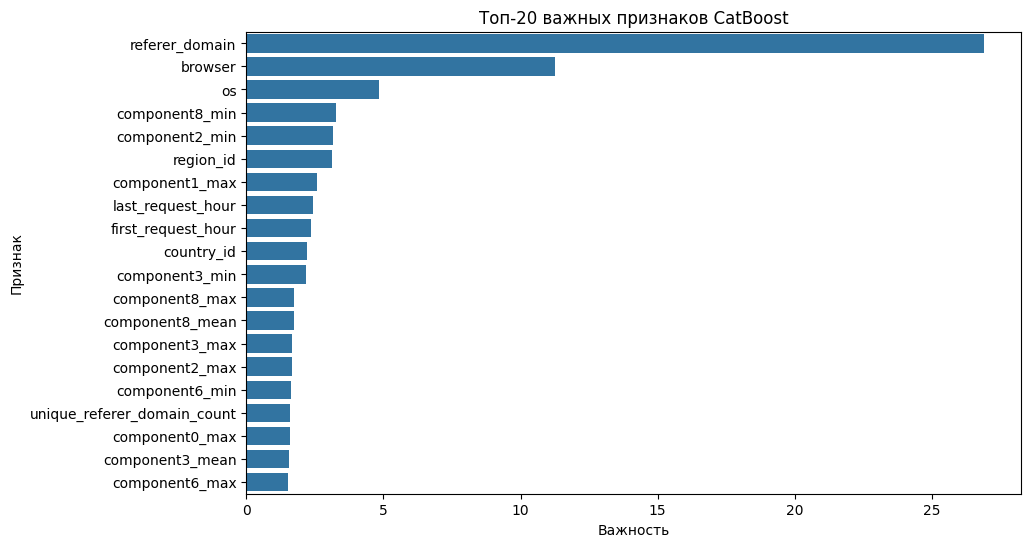

In [150]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(20), x="importance", y="feature")
plt.title("Топ-20 важных признаков CatBoost")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.show()

Наиболее важным признаком для CatBoost оказался `referer_domain`. Это согласуется с EDA, ранее было видно, что разные домены имеют заметно разное распределение `target`.

Также в топ важных признаков вошли `browser` и `os`, то есть информация из `user_agent`. Технический профиль устройства и браузера пользователя помогает модели различать классы.

Среди числовых URL-компонент особенно важны признаки на основе `component8`, `component2`, `component3` и `component6`.

Географические признаки `region_id` и `country_id` тоже вошли в топ, это подтверждает связь географии с целевой переменной

#### LGBMClassifier

Дополнительно обучим `LGBMClassifier`

- градиентный бустинг над решающими деревьями.  
Он хорошо работает с табличными данными и часто показывает сильное качество на задачах классификации.

Для простоты используем тот же подход, что и для LogisticRegression:

- числовые признаки передаем без масштабирования
- категориальные признаки кодируем через OneHotEncoder

In [151]:
lgbm_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [152]:
lgbm_model = Pipeline(
    steps=[
        ("preprocessor", lgbm_preprocessor),
        (
            "model",
            LGBMClassifier(
                n_estimators=500,
                learning_rate=0.05,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [153]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 190784, number of negative: 209216
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.242714 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12639
[LightGBM] [Info] Number of data points in the train set: 400000, number of used features: 1226
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.476960 -> initscore=-0.092225
[LightGBM] [Info] Start training from score -0.092225


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [154]:
lgbm_pred = lgbm_model.predict(X_valid)
lgbm_pred_proba = lgbm_model.predict_proba(X_valid)[:, 1]

In [155]:
lgbm_metrics = get_metrics(y_valid, lgbm_pred, lgbm_pred_proba)

lgbm_metrics

{'roc_auc': 0.9128202775064959, 'accuracy': 0.85117, 'f1': 0.8431172061939347}

In [156]:
model_results = pd.concat(
    [model_results, pd.DataFrame([{"model": "LGBMClassifier", **lgbm_metrics}])],
    ignore_index=True,
)
model_results = model_results.sort_values("roc_auc", ascending=False)
model_results

,model,roc_auc,accuracy,f1
0,CatBoostClassifier,0.9276,0.8699,0.8628
3,LGBMClassifier,0.9128,0.8512,0.8431
1,LogisticRegression,0.8566,0.7929,0.7773
2,DummyClassifier,0.5017,0.5028,0.4788


### RandomForestClassifier

Для RandomForest используем preprocessing:
- числовые признаки оставим без масштабирования
- категориальные признаки закодируем через OneHotEncoder

In [157]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

In [158]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=12,
                min_samples_leaf=20,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [159]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [160]:
rf_pred = rf_model.predict(X_valid)
rf_pred_proba = rf_model.predict_proba(X_valid)[:, 1]

In [161]:
rf_metrics = get_metrics(y_valid, rf_pred, rf_pred_proba)

rf_metrics

{'roc_auc': 0.8356516845089899, 'accuracy': 0.76585, 'f1': 0.7422759842823021}

In [162]:
model_results = pd.concat(
    [model_results, pd.DataFrame([{"model": "RandomForestClassifier", **rf_metrics}])],
    ignore_index=True,
)

In [163]:
model_results = model_results.sort_values("roc_auc", ascending=False)
model_results

,model,roc_auc,accuracy,f1
0,CatBoostClassifier,0.9276,0.8699,0.8628
1,LGBMClassifier,0.9128,0.8512,0.8431
2,LogisticRegression,0.8566,0.7929,0.7773
4,RandomForestClassifier,0.8357,0.7659,0.7423
3,DummyClassifier,0.5017,0.5028,0.4788


## Сравнение качества моделей

Сравним обученные модели по трем метрикам:

- `ROC-AUC` - основная метрика проекта
- `accuracy` - доля правильных предсказаний
- `F1-score` - баланс между precision и recall для класса `1`

In [164]:
model_results

,model,roc_auc,accuracy,f1
0,CatBoostClassifier,0.9276,0.8699,0.8628
1,LGBMClassifier,0.9128,0.8512,0.8431
2,LogisticRegression,0.8566,0.7929,0.7773
4,RandomForestClassifier,0.8357,0.7659,0.7423
3,DummyClassifier,0.5017,0.5028,0.4788


По результатам сравнения лучшей моделью стала `CatBoostClassifier`.

Она показала наибольшее качество по всем метрикам:
- `ROC-AUC = 0.9276`
- `accuracy = 0.8699`
- `F1 = 0.8628`

`LGBMClassifier` также показал сильный результат, но уступил CatBoost по всем метрикам.

`LogisticRegression` оказалась хорошим baseline: она заметно лучше случайной модели, но хуже бустинговых алгоритмов.

`RandomForestClassifier` показал качество ниже LogisticRegression. Это может быть связано с высокой кардинальностью категориальных признаков и тем, что бустинговые модели лучше работают с такими табличными данными.

`DummyClassifier` показал качество около случайного угадывания, что ожидаемо для модели, которая не использует признаки.

## Подбор гиперпараметров лучшей модели

CatBoostClassifier уже показал лучшее качество среди моделей.  
Попробуем улучшить его результат с помощью Grid Search - перебора нескольких заранее заданных комбинаций гиперпараметров.

Чтобы не переобучиться на основной валидационной выборке, для подбора параметров разделим `X_train` на две части:

- `grid_train` - для обучения моделей во время подбора
- `grid_valid` - для выбора лучшей комбинации параметров

Основную выборку `X_valid` оставим для финальной оценки

Создадим выборки для подбора параметров

In [165]:
X_grid_train, X_grid_valid, y_grid_train, y_grid_valid = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train
)

In [166]:
print("X_grid_train:", X_grid_train.shape)
print("X_grid_valid:", X_grid_valid.shape)

X_grid_train: (300000, 55)
X_grid_valid: (100000, 55)


In [167]:
from sklearn.model_selection import ParameterGrid

Подготовим данные для CatBoost

In [168]:
X_grid_train_cb = X_grid_train.copy()
X_grid_valid_cb = X_grid_valid.copy()

In [169]:
for col in categorical_features:
    X_grid_train_cb[col] = X_grid_train_cb[col].astype(str)
    X_grid_valid_cb[col] = X_grid_valid_cb[col].astype(str)

Возьмем небольшую сетку, чтобы подбор не выполнялся слишком долго.

Будем подбирать:

- `depth` - глубину деревьев
- `learning_rate` - скорость обучения
- `l2_leaf_reg` - регуляризацию

In [170]:
param_grid = {
    "depth": [6, 7],
    "learning_rate": [0.10, 0.12],
    "l2_leaf_reg": [3],
}
grid = list(ParameterGrid(param_grid))

In [171]:
print("Количество комбинаций:", len(grid))

Количество комбинаций: 4


Для каждой комбинации параметров обучим CatBoost и посчитаем ROC-AUC на `grid_valid`

In [172]:
grid_search_results = []

In [173]:
for i, params in enumerate(grid, start=1):
    print(f"Комбинация {i}/{len(grid)}")
    print(params)
    model = CatBoostClassifier(
        iterations=800,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=42,
        verbose=0,
        allow_writing_files=False,
        **params,
    )
    model.fit(
        X_grid_train_cb,
        y_grid_train,
        cat_features=categorical_features,
        eval_set=(X_grid_valid_cb, y_grid_valid),
        early_stopping_rounds=70,
        use_best_model=True,
    )
    pred_proba = model.predict_proba(X_grid_valid_cb)[:, 1]
    auc = roc_auc_score(y_grid_valid, pred_proba)
    grid_search_results.append(
        {**params, "best_iteration": model.get_best_iteration(), "roc_auc": auc}
    )

    print("ROC-AUC:", round(auc, 5))
    print()

Комбинация 1/4
{'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
ROC-AUC: 0.92837

Комбинация 2/4
{'depth': 6, 'l2_leaf_reg': 3, 'learning_rate': 0.12}
ROC-AUC: 0.92919

Комбинация 3/4
{'depth': 7, 'l2_leaf_reg': 3, 'learning_rate': 0.1}
ROC-AUC: 0.93104

Комбинация 4/4
{'depth': 7, 'l2_leaf_reg': 3, 'learning_rate': 0.12}
ROC-AUC: 0.93147



Посмотрим лучшие параметры

In [174]:
grid_search_results = pd.DataFrame(grid_search_results)

In [175]:
grid_search_results = grid_search_results.sort_values("roc_auc", ascending=False)
grid_search_results

,depth,l2_leaf_reg,learning_rate,best_iteration,roc_auc
3,7,3,0.1200,799,0.9315
2,7,3,0.1000,796,0.9310
1,6,3,0.1200,798,0.9292
0,6,3,0.1000,799,0.9284


In [176]:
best_grid_params = {
    "depth": int(grid_search_results.iloc[0]["depth"]),
    "learning_rate": float(grid_search_results.iloc[0]["learning_rate"]),
    "l2_leaf_reg": float(grid_search_results.iloc[0]["l2_leaf_reg"]),
}
best_grid_params

{'depth': 7, 'learning_rate': 0.12, 'l2_leaf_reg': 3.0}

Лучшей комбинацией параметров на внутренней валидации стала:

- `depth = 7`
- `learning_rate = 0.12`
- `l2_leaf_reg = 3`

На `grid_valid` эта конфигурация показала ROC-AUC около 0.9315.

Теперь обучим CatBoost с этими параметрами на полном `X_train` и оценим качество на основной валидационной выборке `X_valid`

Обучим данный CatBoost на всей обучающей части и проверим его на основной валидационной выборке

In [177]:
X_train_tuned_cb = X_train.copy()
X_valid_tuned_cb = X_valid.copy()

In [178]:
for col in categorical_features:
    X_train_tuned_cb[col] = X_train_tuned_cb[col].astype(str)
    X_valid_tuned_cb[col] = X_valid_tuned_cb[col].astype(str)

In [179]:
grid_catboost_model = CatBoostClassifier(
    iterations=1000,
    depth=best_grid_params["depth"],
    learning_rate=best_grid_params["learning_rate"],
    l2_leaf_reg=best_grid_params["l2_leaf_reg"],
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    allow_writing_files=False,
)

grid_catboost_model.fit(
    X_train_tuned_cb,
    y_train,
    cat_features=categorical_features,
    eval_set=(X_valid_tuned_cb, y_valid),
    early_stopping_rounds=100,
    use_best_model=True,
)

0:	test: 0.8480128	best: 0.8480128 (0)	total: 666ms	remaining: 11m 4s
100:	test: 0.9167229	best: 0.9167229 (100)	total: 1m 33s	remaining: 13m 54s
200:	test: 0.9250766	best: 0.9250766 (200)	total: 2m 59s	remaining: 11m 53s
300:	test: 0.9283704	best: 0.9283704 (300)	total: 4m 20s	remaining: 10m 5s
400:	test: 0.9302186	best: 0.9302186 (400)	total: 5m 43s	remaining: 8m 32s
500:	test: 0.9312844	best: 0.9312844 (500)	total: 7m 16s	remaining: 7m 14s
600:	test: 0.9321921	best: 0.9321921 (600)	total: 8m 46s	remaining: 5m 49s
700:	test: 0.9328066	best: 0.9328066 (700)	total: 10m 15s	remaining: 4m 22s
800:	test: 0.9333490	best: 0.9333490 (800)	total: 12m	remaining: 2m 59s
900:	test: 0.9337975	best: 0.9337975 (900)	total: 13m 24s	remaining: 1m 28s
999:	test: 0.9341445	best: 0.9341445 (999)	total: 14m 50s	remaining: 0us

bestTest = 0.9341445345
bestIteration = 999



CatBoostClassifier(allow_writing_files=False, depth=7, eval_metric='AUC', iterations=1000, l2_leaf_reg=3.0, learning_rate=0.12, loss_function='Logloss', random_seed=42, verbose=100)

In [180]:
grid_catboost_pred = grid_catboost_model.predict(X_valid_tuned_cb)
grid_catboost_pred_proba = grid_catboost_model.predict_proba(X_valid_tuned_cb)[:, 1]

In [181]:
grid_catboost_metrics = get_metrics(y_valid, grid_catboost_pred, grid_catboost_pred_proba)
grid_catboost_metrics

{'roc_auc': 0.9341445345173378, 'accuracy': 0.87698, 'f1': 0.8701937281053476}

Добавим tuned CatBoost в таблицу сравнения

In [182]:
model_results = model_results[model_results["model"] != "CatBoostClassifier grid tuned"]
model_results = pd.concat(
    [
        model_results,
        pd.DataFrame(
            [{"model": "CatBoostClassifier grid tuned", **grid_catboost_metrics}]
        ),
    ],
    ignore_index=True,
)

In [183]:
model_results = model_results.sort_values("roc_auc", ascending=False)
model_results

,model,roc_auc,accuracy,f1
5,CatBoostClassifier grid tuned,0.9341,0.8770,0.8702
0,CatBoostClassifier,0.9276,0.8699,0.8628
1,LGBMClassifier,0.9128,0.8512,0.8431
2,LogisticRegression,0.8566,0.7929,0.7773
3,RandomForestClassifier,0.8357,0.7659,0.7423
4,DummyClassifier,0.5017,0.5028,0.4788


Grid Search улучшил качество CatBoostClassifier.

После подбора гиперпараметров ROC-AUC вырос с 0.9276 до 0.9341.  
Также улучшились accuracy и F1-score

## Обучение финальной модели на всех обучающих данных


По результатам сравнения лучшей моделью стала `CatBoostClassifier grid tuned`.

Финальная модель будет обучена на всей обучающей выборке `train_user_features`, чтобы использовать максимум доступных размеченных данных.

Для обучения используем лучшие параметры, найденные через Grid Search:

- `depth = 7`
- `learning_rate = 0.12`
- `l2_leaf_reg = 3`

In [184]:
X_full = train_user_features.drop(columns=["user_id", "target"])
y_full = train_user_features["target"]
X_test = test_user_features.drop(columns=["user_id"])

In [185]:
print("X_full:", X_full.shape)
print("y_full:", y_full.shape)
print("X_test:", X_test.shape)

X_full: (500000, 55)
y_full: (500000,)
X_test: (85000, 55)


In [186]:
categorical_features_final = X_full.select_dtypes(include="object").columns.tolist()

In [187]:
X_full_cb = X_full.copy()
X_test_cb = X_test.copy()

In [188]:
for col in categorical_features_final:
    X_full_cb[col] = X_full_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

In [189]:
print("Категориальные признаки:", categorical_features_final)

Категориальные признаки: ['country_id', 'region_id', 'timezone_id', 'referer_domain', 'browser', 'os']


In [190]:
final_model = CatBoostClassifier(
    iterations=1000,
    depth=7,
    learning_rate=0.12,
    l2_leaf_reg=3,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=100,
    allow_writing_files=False,
)

final_model.fit(X_full_cb, y_full, cat_features=categorical_features_final)

0:	total: 925ms	remaining: 15m 23s
100:	total: 1m 34s	remaining: 14m 2s
200:	total: 3m 31s	remaining: 14m 1s
300:	total: 5m 12s	remaining: 12m 5s
400:	total: 7m 24s	remaining: 11m 3s
500:	total: 9m 18s	remaining: 9m 16s
600:	total: 11m 15s	remaining: 7m 28s
700:	total: 12m 52s	remaining: 5m 29s
800:	total: 14m 30s	remaining: 3m 36s
900:	total: 16m 9s	remaining: 1m 46s
999:	total: 18m 22s	remaining: 0us


CatBoostClassifier(allow_writing_files=False, depth=7, eval_metric='AUC', iterations=1000, l2_leaf_reg=3, learning_rate=0.12, loss_function='Logloss', random_seed=42, verbose=100)

In [191]:
print(classification_report(y_valid, grid_catboost_pred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88     52304
           1       0.88      0.86      0.87     47696

    accuracy                           0.88    100000
   macro avg       0.88      0.88      0.88    100000
weighted avg       0.88      0.88      0.88    100000



In [192]:
cm = confusion_matrix(y_valid, grid_catboost_pred)
cm_df = pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"])
cm_df

,pred_0,pred_1
true_0,46463,5841
true_1,6461,41235


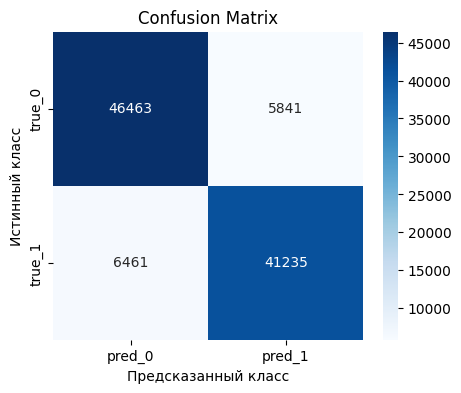

In [193]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

Финальная модель обучена на всей обучающей выборке.  
Далее используем ее для предсказания `target` для пользователей из `test_users`

## Формирование предсказаний для тестовых пользователей

Сделаем предсказания для `test_user_features`.

Для итогового файла нужен формат:

- `user_id`
- `target`

где `target` - предсказанный класс `0` или `1`

In [194]:
test_pred_proba = final_model.predict_proba(X_test_cb)[:, 1]
test_pred = (test_pred_proba >= 0.5).astype(int)

In [195]:
submission = pd.DataFrame({"user_id": test_user_features["user_id"], "target": test_pred})

In [196]:
submission.head()

,user_id,target
0,c2802dadd33d8ae09bb366bdd41212ea,0
1,e5b1988db74527ec092f28b0bbfdaac9,0
2,6ef1eedbdb72554e53e69782066065c5,1
3,7e057293ecae62985a327b7af51858ea,0
4,a27bd7ce8828497823fa8d5d05e7bbf7,0


In [197]:
print("Размер submission:", submission.shape)
print("Размер test_users:", test_users.shape)
print("Уникальных user_id:", submission["user_id"].nunique())
print("Пропусков:", submission.isna().sum().sum())
print("Уникальные target:", sorted(submission["target"].unique()))

Размер submission: (85000, 2)
Размер test_users: (85000, 1)
Уникальных user_id: 85000
Пропусков: 0
Уникальные target: [np.int64(0), np.int64(1)]


In [198]:
assert submission["user_id"].equals(test_users["user_id"])

Подведем итоги

In [199]:
model_results_clean = (
    model_results.drop(columns=["index"], errors="ignore")
    .drop_duplicates(subset="model", keep="first")
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
model_results_clean

,model,roc_auc,accuracy,f1
0,CatBoostClassifier grid tuned,0.9341,0.8770,0.8702
1,CatBoostClassifier,0.9276,0.8699,0.8628
2,LGBMClassifier,0.9128,0.8512,0.8431
3,LogisticRegression,0.8566,0.7929,0.7773
4,RandomForestClassifier,0.8357,0.7659,0.7423
5,DummyClassifier,0.5017,0.5028,0.4788


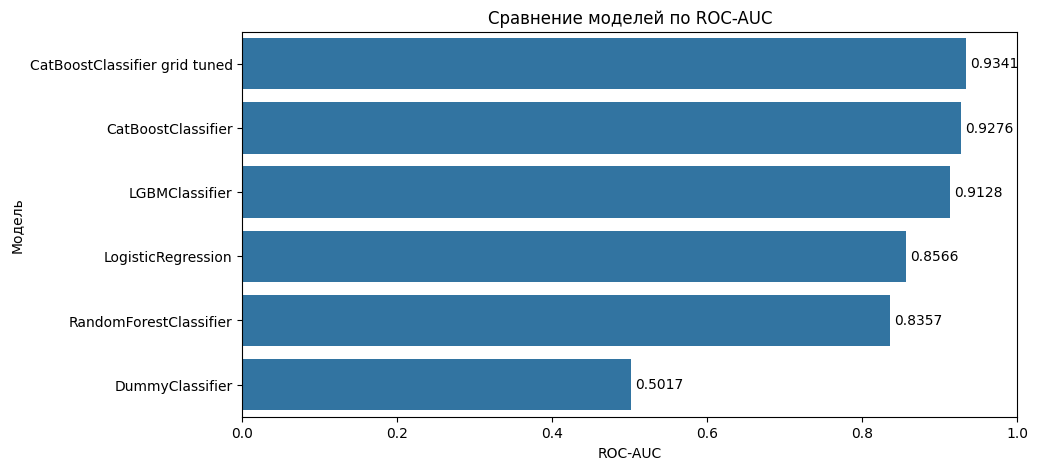

In [200]:
plt.figure(figsize=(10, 5))
ax = sns.barplot(data=model_results_clean, x="roc_auc", y="model")
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3)
plt.title("Сравнение моделей по ROC-AUC")
plt.xlabel("ROC-AUC")
plt.ylabel("Модель")
plt.xlim(0, 1)
plt.show()

In [201]:
model_results_long = model_results_clean.melt(
    id_vars="model",
    value_vars=["roc_auc", "accuracy", "f1"],
    var_name="metric",
    value_name="score",
)
model_results_long.head()

,model,metric,score
0,CatBoostClassifier grid tuned,roc_auc,0.9341
1,CatBoostClassifier,roc_auc,0.9276
2,LGBMClassifier,roc_auc,0.9128
3,LogisticRegression,roc_auc,0.8566
4,RandomForestClassifier,roc_auc,0.8357


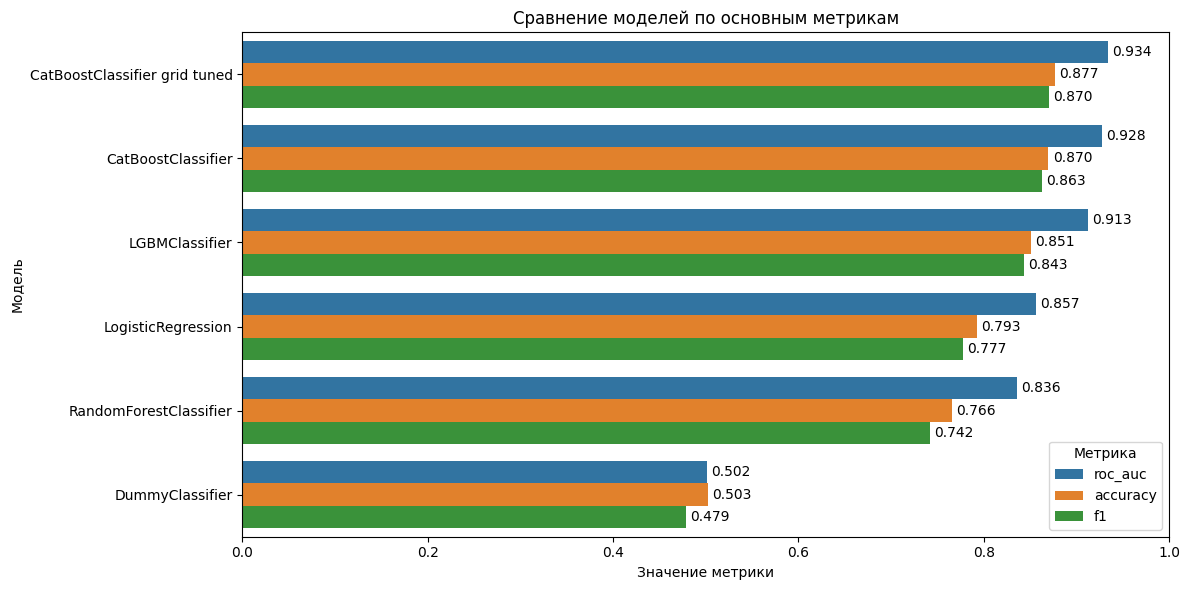

In [202]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=model_results_long, x="score", y="model", hue="metric")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.title("Сравнение моделей по основным метрикам")
plt.xlabel("Значение метрики")
plt.ylabel("Модель")
plt.xlim(0, 1)
plt.legend(title="Метрика")
plt.tight_layout()
plt.show()

In [203]:
final_feature_importance = pd.DataFrame(
    {"feature": X_full_cb.columns, "importance": final_model.get_feature_importance()}
)

final_feature_importance = final_feature_importance.sort_values(
    "importance", ascending=False
)

final_feature_importance.head(20)

,feature,importance
12,referer_domain,20.6172
13,browser,9.4065
14,os,5.0818
10,region_id,3.8783
25,component2_min,3.4153
7,first_request_hour,2.9769
8,last_request_hour,2.8914
22,component1_max,2.6783
29,component3_min,2.6235
49,component8_min,2.6152


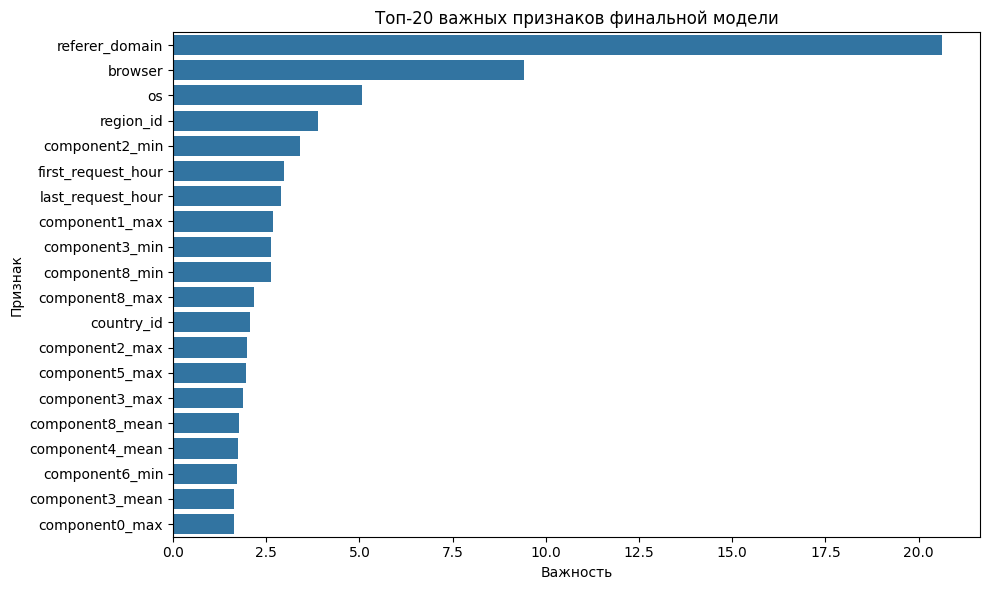

In [204]:
plt.figure(figsize=(10, 6))
sns.barplot(data=final_feature_importance.head(20), x="importance", y="feature")
plt.title("Топ-20 важных признаков финальной модели")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

In [205]:
submission_distribution = submission["target"].value_counts(normalize=True).sort_index().reset_index()
submission_distribution.columns = ["target", "share"]
submission_distribution

,target,share
0,0,0.5288
1,1,0.4712


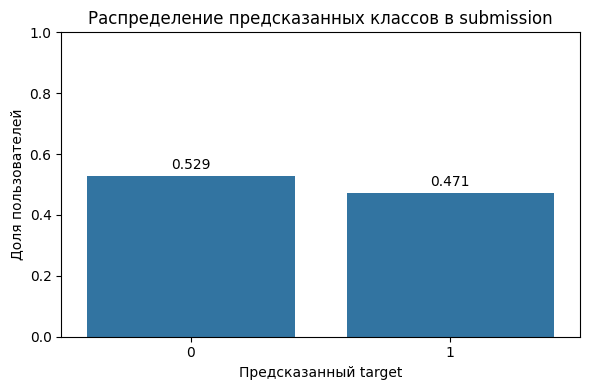

In [206]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(data=submission_distribution, x="target", y="share")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
plt.title("Распределение предсказанных классов в submission")
plt.xlabel("Предсказанный target")
plt.ylabel("Доля пользователей")
plt.ylim(0, 1)
plt.tight_layout()

plt.show()

## Сохранение модели и результатов

Сохраним файл с предсказаниями и обученную модель

In [207]:
submission.to_csv("submission.csv", index=False)

In [208]:
joblib.dump(final_model, "catboost_final_model.joblib")

['catboost_final_model.joblib']

## Заключение

В рамках проекта была решена задача бинарной классификации пользователей социальных сетей по закодированному полу на основе данных о рекламных событиях.

Проект выполнен в контексте бизнес-задачи рекламного таргетинга. Для рекламной платформы важно лучше понимать аудиторию, чтобы показывать пользователям более релевантные объявления. Более точное определение пользовательских характеристик может помочь рекламодателям эффективнее настраивать кампании, снижать долю нерелевантных показов и рациональнее расходовать рекламный бюджет.

#### Проделанная работа

В начале проекта были загружены и изучены исходные данные:

- `train.csv` и `test.csv` - таблицы рекламных событий
- `train_labels.csv` - целевая переменная на уровне пользователя
- `test_users.csv` - список пользователей для итогового предсказания
- `referer_vectors.csv` - числовые векторные представления URL
- `geo_info.csv` - географическая информация

Первичный анализ показал, что исходные данные находятся на уровне рекламных событий, а целевая переменная задана на уровне пользователя. Поэтому ключевым этапом проекта стало агрегирование данных до уровня `user_id`.

На этапе предобработки были выполнены следующие действия:
- удалены полные дубликаты
- обработан пропуск в `user_agent`
- пропуски в `region_id` заменены на отдельную категорию `unknown`
- `request_ts` преобразован в datetime
- проверены ключи для объединения таблиц
- события были обогащены URL-векторами, географией и целевой переменной

В ходе EDA были исследованы распределения целевой переменной, количества событий на пользователя, временных признаков, географии, referer, браузеров, операционных систем и URL-компонент.

Анализ показал несколько важных закономерностей:

- целевая переменная достаточно сбалансирована
- большинство пользователей имеют только одно рекламное событие
- географические признаки связаны с target
- браузер и операционная система также дают полезный сигнал
- самый сильный категориальный сигнал наблюдается у `referer_domain`
- URL-компоненты различаются между классами и могут быть полезны для модели

На этапе feature engineering события были агрегированы до уровня пользователя. Для каждого `user_id` были сформированы признаки активности, разнообразия URL и географии, первые категориальные значения, а также агрегаты по URL-компонентам: среднее, стандартное отклонение, минимум и максимум

#### Обучение моделей

Для решения задачи были обучены модели разной сложности:
- `DummyClassifier` — случайный baseline
- `LogisticRegression` — простой линейный baseline
- `RandomForestClassifier` — ансамблевая модель на решающих деревьях
- `LGBMClassifier` — градиентный бустинг
- `CatBoostClassifier` — градиентный бустинг, хорошо работающий с категориальными признаками

В качестве основной метрики была выбрана ROC-AUC, так как задача является бинарной классификацией, важно оценивать итоговый класс и качество ранжирования пользователей по вероятности принадлежности к классу.

Лучший результат среди базовых моделей показал CatBoostClassifier. После этого для него был выполнен небольшой Grid Search по ключевым гиперпараметрам: `depth`, `learning_rate` и `l2_leaf_reg`.

Подбор гиперпараметров улучшил качество модели. Финальной моделью стала `CatBoostClassifier grid tuned`.

На валидационной выборке финальная модель показала:
- ROC-AUC: 0.9341
- accuracy: 0.8780
- F1-score: 0.8702

Анализ важности признаков показал, что наиболее полезными для модели оказались:
- `referer_domain`
- браузер пользователя
- операционная система
- географические признаки
- агрегаты по URL-компонентам

Это согласуется с результатами EDA. Разные домены referer имели заметно разное распределение target, а признаки из user-agent и географии также показывали различия между классами. URL-компоненты не имеют прямой бизнес-интерпретации, но они содержат полезную информацию о страницах, на которых происходили рекламные события

#### Ответ на бизнес-цель

Бизнес-цель проекта заключалась в повышении эффективности рекламного таргетинга за счет автоматического определения пола пользователя.

Построенная модель решает эту задачу на уровне `user_id` и может использоваться как дополнительный инструмент сегментации аудитории. Предсказания модели могут помочь рекламной платформе:
- точнее определять целевую аудиторию
- показывать объявления более релевантным пользователям
- снижать долю нецелевых рекламных показов
- повышать эффективность рекламных кампаний
- рациональнее использовать рекламный бюджет клиента
- повышать привлекательность рекламной платформы для рекламодателей

#### Ограничения проекта

У проекта есть несколько важных ограничений.

- данные покрывают короткий временной период. Поэтому модель была проверена на случайном разбиении пользователей, но перед реальным внедрением ее желательно дополнительно протестировать на данных другого периода.

- большинство пользователей имеют только одно рекламное событие. Это ограничивает возможность построения более сложных поведенческих признаков.

- целевая переменная закодирована. Поэтому классы `0` и `1` рассматриваются как абстрактные категории, без прямой интерпретации конкретного пола.

- качество модели оценивалось на валидационной выборке. Реальный бизнес-эффект можно подтвердить через продуктовый эксперимент

#### Рекомендации

Для дальнейшего развития проекта можно предложить следующие шаги.

1. Проверить модель на временной отложенной выборке. Это позволит оценить, насколько качество стабильно на новых данных.
2. Использовать вероятности модели как скоринг для рекламных систем, не только итоговые классы `0/1`.
3. Подобрать оптимальный порог классификации под конкретную бизнес-задачу. Если важнее точность попадания в сегмент, можно повысить порог; если важнее охват аудитории, можно снизить порог.
4. Добавить дополнительные признаки: версии браузера и операционной системы, полный referer как категориальный признак для CatBoost, признаки повторной активности и дополнительные временные агрегаты.
5. Настроить мониторинг модели после внедрения (отслеживать распределение признаков, распределение предсказаний, качество на новых данных и т.д.)
6. Проверить бизнес-эффект через A/B-тест. Например, сравнить рекламные кампании с использованием модели и без нее по CTR, конверсии и стоимости целевого действия